# 🔍 Model Interpretability — Permutation Importance, PDP/ICE, SHAP, LIME, and Counterfactuals

> **What you'll learn:** how to explain *what* a model relies on (global) and *why* it made one decision (local) — standardized coefficients and odds ratios, the bias of impurity importance, permutation importance on held-out data and what correlated features do to it, partial dependence and ICE curves (and when they lie), Shapley values from first principles, SHAP for trees and for any model (with the additivity check in log-odds), LIME and its run-to-run instability, counterfactual "what would flip the decision?" search, proxies and the causality trap, and explanations as a debugging tool for leakage — plus exact Shapley values and permutation importance built from scratch that match `shap` and scikit-learn.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Imbalanced Data and Model Evaluation](17_Imbalanced_Data_and_Model_Evaluation.ipynb) (the previous notebook in this series: metrics, thresholds) · [Gradient Boosting](10_Gradient_Boosting.ipynb) (LightGBM, and a first look at SHAP) · [Decision Trees](08_Decision_Trees.ipynb) (readable rules, impurity importance bias) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · shap 0.52 · lime 0.2 · lightgbm 4.7 · numpy 2.5 · pandas 3.0 |
| **Interview relevance** | ⭐⭐⭐ Very high — "SHAP vs LIME", "why is feature importance misleading?", "what are Shapley values?", "permutation importance with correlated features", "does SHAP show causality?", "how would you produce adverse-action reasons for a credit model?" |

## 🤔 What Is Model Interpretability?

Imagine a bank's loan officer who says *"denied"* and nothing else. You'd want to know **why** — and whether the reason is fair. **Interpretability** is the toolkit for getting those answers out of a machine learning model.

| Term | Plain English |
|---|---|
| **Global explanation** | what the model relies on **overall** ("income and education matter most") |
| **Local explanation** | why the model scored **one row** the way it did ("*your* short credit history pushed the score up") |
| **Intrinsic (glass-box)** | the model itself is readable: a linear model's weights, a shallow tree's rules |
| **Post-hoc** | a separate method explains an already-trained model (permutation importance, SHAP, LIME) |
| **Model-specific** | works only for one model family and uses its internals (TreeSHAP reads tree structure) |
| **Model-agnostic** | only calls `predict` — works for any model |
| **Attribution** | a number per feature saying how much it pushed one prediction up or down |

**Analogy:** a football team wins 3–0. *Global*: "our defence is our strength this season". *Local*: "today, the striker was worth +2 goals". **Shapley values** — the heart of SHAP — are the fair way to split the team's result between players who only score *together*.

One warning up front, repeated all notebook: an explanation describes **the model**, not **the world**. "The model uses marital status" does not mean "getting married raises your income".

## 🎯 Why It Matters

- **Debugging.** Explanations catch leakage ("why is `days_since_account_closed` the top feature?"), spurious shortcuts, and broken pipelines *before* a model ships. Section 12 and Pitfall 1 show a leaky feature exposed by SHAP in seconds.
- **Trust and adoption.** Doctors, underwriters, and fraud analysts act on a score only when they can see what drove it.
- **Regulation.** In US consumer credit, the Equal Credit Opportunity Act and Regulation B require **specific reasons** for adverse actions (e.g. a denied loan) — the CFPB has stated that using a complex algorithm is no excuse. The EU AI Act classifies creditworthiness scoring as high-risk, with transparency duties. Per-applicant **reason codes** built from SHAP values are a common industry answer (the mini project builds them).
- **Fairness.** Explanations reveal whether a model leans on protected attributes or their **proxies** (section 12).
- **In interviews** this is asked in every tabular-ML loop and most ML system-design rounds: *"How do you explain a gradient-boosting model?"*, *"SHAP vs LIME?"*, *"Why can't I trust `feature_importances_`?"*, *"Two features are 95% correlated — what happens to their importance?"*, *"Does a high SHAP value mean the feature causes the outcome?"*, *"Design reason codes for a credit model."* Every one is answered with an experiment below.

## 🃏 Algorithm Card

This notebook covers **techniques**, not a single algorithm, so the card has one column per method (same rows as every notebook in the series).

| | Coefficients (linear / logistic) | Impurity importance (MDI, split gain) | Permutation importance | PDP / ICE | SHAP | LIME |
|---|---|---|---|---|---|---|
| **Learning type** | intrinsic, model-specific, global | post-hoc, model-specific (trees), global | post-hoc, model-agnostic, global | post-hoc, model-agnostic; PDP global, ICE local | post-hoc; model-agnostic (Exact, Permutation, Kernel) or fast model-specific (Tree, Linear); local → global by averaging | post-hoc, model-agnostic, local |
| **Tasks** | regression; classification in log-odds | tree models and ensembles | any fitted model + a score | regression; classification (probability or decision function) | any model; classifiers explained in log-odds (raw margin) or probability | classification, regression; tabular, text, images |
| **Model / objective** | weight $w_j$ = change in output per unit of $x_j$, others fixed | sum of impurity decreases (or number of splits) on $x_j$, measured on **training** data | $\text{score}(X) - \text{score}(X \text{ with column } j \text{ shuffled})$, averaged over repeats | $\text{PD}_j(v) = \frac1n\sum_i f(v, x_{i,-j})$; ICE keeps each row's curve | Shapley value $\phi_j=\sum_{S}\frac{\lvert S\rvert!(M-\lvert S\rvert-1)!}{M!}\,[v(S\cup\{j\})-v(S)]$, $v(S)=\mathbb E[f(x_S, X_{\bar S})]$, so $f(x)=\phi_0+\sum_j\phi_j$ | weighted linear surrogate $\min_g\sum_z \pi_x(z)\,(f(z)-g(z))^2+\Omega(g)$ around one row |
| **Key hyperparameters** | regularization `C`, feature scaling, encoding | `importance_type` (`"split"` / `"gain"`) | `n_repeats` (5–30), `scoring`, `max_samples`, **which data** (held-out) | `grid_resolution` (20–100), `percentiles`, `subsample` (ICE), `centered` | background/masker size (50–1,000), `feature_perturbation`, `max_evals` | `kernel_width` (default $0.75\sqrt{d}$), `num_samples` (1k–10k), `num_features`, discretization |
| **Needs feature scaling?** | **yes** to compare magnitudes | no | no | no | no | internally standardizes to measure distances |
| **Handles missing values / categoricals?** | encode and impute first; one weight per one-hot level | whatever the tree handles | yes — shuffles any column; **group** one-hot columns | categorical features supported; missing depends on the model | yes per input column; one-hot SHAP values can be summed per original feature | categorical features sampled from training frequencies |
| **Training & prediction complexity** | free after fitting | free after fitting | $d \times$ `n_repeats` scorings of held-out data | grid size × rows predictions per feature | exact: $2^M$ coalitions × background rows; TreeSHAP path-dependent $O(TLD^2)$ per row; interventional $O(TLB)$ | `num_samples` predictions + one small ridge fit per row |
| **Interpretability** | exact for the model (if features are not collinear) | rough ranking only | global, in units of lost score | average effect shape + heterogeneity | additive per-row attributions that sum to the prediction | approximate, local, can change between runs |
| **Strengths** | free, exact, odds ratios | instant | model-agnostic, honest on held-out data, simple | shows *shape* (monotone, threshold, saturation) | theory (efficiency, symmetry, dummy, additivity), local + global, fast for trees | any model and data type, intuitive "local line" |
| **Weaknesses** | only as good as the linear fit; collinearity makes weights unstable | biased toward high-cardinality/continuous features; training data | correlated features share or hide importance; extrapolates to impossible rows | averages hide interactions; extrapolates when features correlate | costly for non-trees; interventional version breaks correlations; not causal | unstable; kernel width arbitrary; surrogate may fit poorly |
| **Use it when** | the model is linear/logistic, or you need a glass-box | a quick first look at a tree model | a trustworthy global ranking for any model | explaining an effect's shape to stakeholders | per-prediction reasons, global summaries, debugging tree ensembles | a quick local sanity check on a non-tree model, text or images |
| **Avoid it when** | features are unscaled or highly collinear | making decisions about features | features are strongly correlated (group them) | features are strongly correlated (use ALE) | you need causal claims or run-time is critical for large non-tree models | you need stable, auditable explanations |
| **Best libraries** | scikit-learn, statsmodels | scikit-learn, LightGBM, XGBoost | `sklearn.inspection.permutation_importance` | `sklearn.inspection.PartialDependenceDisplay` | `shap` (`TreeExplainer`, `Explainer`, `LinearExplainer`) | `lime` (`LimeTabularExplainer`) |

## ✅ By the End You Can

- [ ] Place any explanation method on the map: global vs local, intrinsic vs post-hoc, model-specific vs model-agnostic
- [ ] Read standardized coefficients and odds ratios, and show why impurity importance is biased while permutation importance on held-out data is not — and what correlated features do to both
- [ ] Draw and critique partial dependence and ICE plots, including when they extrapolate into impossible data
- [ ] Compute Shapley values by hand, use SHAP's tree, permutation and linear explainers, verify additivity in log-odds, and read waterfall, beeswarm, bar and scatter plots
- [ ] Measure LIME's instability, search for counterfactuals, and spot proxies, leakage and causal over-reach in explanations
- [ ] Implement exact Shapley values and permutation importance from scratch and match `shap` and scikit-learn

## 📋 Table of Contents

1. [The Interpretability Map: Global vs Local, Intrinsic vs Post-hoc](#1.-The-Interpretability-Map:-Global-vs-Local,-Intrinsic-vs-Post-hoc-🟢)
2. [Intrinsically Interpretable Models: Coefficients and Odds Ratios](#2.-Intrinsically-Interpretable-Models:-Coefficients-and-Odds-Ratios-🟢)
3. [Permutation Importance vs Impurity Importance](#3.-Permutation-Importance-vs-Impurity-Importance-🟡)
4. [Correlated Features: Split Credit and Grouped Permutation](#4.-Correlated-Features:-Split-Credit-and-Grouped-Permutation-🔴)
5. [Partial Dependence and ICE Plots](#5.-Partial-Dependence-and-ICE-Plots-🟡)
6. [Shapley Values: Fair Credit From Game Theory](#6.-Shapley-Values:-Fair-Credit-From-Game-Theory-🟡)
7. [TreeSHAP: Exact, Fast, and Additive in Log-Odds](#7.-TreeSHAP:-Exact,-Fast,-and-Additive-in-Log-Odds-🔴)
8. [Reading SHAP Plots: Waterfall, Beeswarm, Bar, Scatter](#8.-Reading-SHAP-Plots:-Waterfall,-Beeswarm,-Bar,-Scatter-🟢)
9. [Model-Agnostic SHAP: Maskers, Permutation, and LinearExplainer](#9.-Model-Agnostic-SHAP:-Maskers,-Permutation,-and-LinearExplainer-🔴)
10. [LIME: Local Surrogates and Their Instability](#10.-LIME:-Local-Surrogates-and-Their-Instability-🔴)
11. [Counterfactual Explanations](#11.-Counterfactual-Explanations-🟡)
12. [Explaining the Model, Not the World: Proxies and Causality](#12.-Explaining-the-Model,-Not-the-World:-Proxies-and-Causality-🔴)
13. [Head-to-Head: Do the Explainers Agree?](#13.-Head-to-Head:-Do-the-Explainers-Agree?-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Explain-a-Credit-Decision) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. Four small real datasets are downloaded once from OpenML / scikit-learn and cached in `_outputs/sklearn_data` (Adult census income, California housing, Titanic, German credit — a few MB in total).

`shap` 0.52 calls a matplotlib colormap method that recent matplotlib marks as *pending deprecation* at import time; we silence exactly that warning around the import, because it comes from inside the library and changes nothing for us.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "scikit-learn>=1.9" "shap>=0.52" "lime>=0.2" "lightgbm>=4.6" "numpy>=2.0" "pandas>=2.2" scipy matplotlib

import importlib.metadata
import itertools
import math
import sys
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import lime.lime_base
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy.stats import spearmanr
from sklearn.compose import make_column_transformer
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, partial_dependence, permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import get_scorer, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.neighbors import KDTree
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils import check_random_state

with warnings.catch_warnings():
    warnings.simplefilter("ignore", PendingDeprecationWarning)   # raised inside shap's colormap setup at import time
    import shap

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print(f"shap {shap.__version__} | lime {importlib.metadata.version('lime')} | lightgbm {lgb.__version__}")

SEED = 42
N_JOBS = 4                                       # modest thread count: other programs share this laptop
np.set_printoptions(precision=4, suppress=True)
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"         # dataset cache
DATA_HOME.mkdir(parents=True, exist_ok=True)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, dtype=float)))


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    try:
        g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, atol=atol, rtol=1e-5)
    except (TypeError, ValueError):
        ok = np.array_equal(np.asarray(got), np.asarray(expected)) if isinstance(expected, (list, np.ndarray)) else got == expected
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | NumPy 2.5.3 | pandas 3.0.5 | scikit-learn 1.9.1
shap 0.52.0 | lime 0.2.0.1 | lightgbm 4.7.0


## 1. The Interpretability Map: Global vs Local, Intrinsic vs Post-hoc 🟢

Our main dataset is **Adult** (48,842 real people from the 1994 US census). **Target:** does the person earn more than $50K a year? We train a **LightGBM** model — hundreds of trees, strong, and impossible to read directly — and spend the notebook explaining it.

Categorical columns (workclass, occupation, …) become integer codes; missing categories become their own `"missing"` level. The code vocabulary is built from the category names only (no targets), so building it before the split does not leak.

In [2]:
adult = fetch_openml("adult", version=2, as_frame=True, data_home=DATA_HOME).frame
adult.columns = [c.replace("-", "_") for c in adult.columns]
CAT_COLS = ["workclass", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]
NUM_COLS = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
FEATURES = ["age", "workclass", "fnlwgt", "education_num", "marital_status", "occupation", "relationship",
            "race", "sex", "capital_gain", "capital_loss", "hours_per_week", "native_country"]

adult_raw = pd.DataFrame(index=adult.index)
for col in FEATURES + ["education"]:
    if col in NUM_COLS:
        adult_raw[col] = adult[col].astype(float)
    else:
        adult_raw[col] = adult[col].astype(object).where(adult[col].notna(), "missing").astype(str)
CATEGORIES = {col: sorted(adult_raw[col].unique()) for col in CAT_COLS + ["education"]}


def to_codes(frame):
    """Replace each categorical column by integer codes from the fixed vocabulary (LightGBM, SHAP and LIME need numbers)."""
    out = {}
    for col in frame.columns:
        out[col] = pd.Categorical(frame[col], categories=CATEGORIES[col]).codes.astype(float) if col in CATEGORIES else frame[col].to_numpy(float)
    return pd.DataFrame(out, index=frame.index)


X_all = to_codes(adult_raw)
y_all = (adult["class"] == ">50K").astype(int).to_numpy()
idx_tr, idx_te = train_test_split(adult.index, test_size=0.25, stratify=y_all, random_state=SEED)
X_tr, X_te = X_all.loc[idx_tr, FEATURES], X_all.loc[idx_te, FEATURES]
y_tr, y_te = y_all[idx_tr], y_all[idx_te]
raw_tr, raw_te = adult_raw.loc[idx_tr], adult_raw.loc[idx_te]
X_explain, y_explain = X_te.iloc[:2000], y_te[:2000]          # a fixed held-out slice we explain repeatedly
print(f"{len(adult):,} adults | {len(FEATURES)} features | positive rate (>50K) {y_all.mean():.1%} | train {len(X_tr):,} / test {len(X_te):,}")

LGBM_PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=0, n_jobs=N_JOBS, verbose=-1)
start = time.perf_counter()
lgbm = lgb.LGBMClassifier(**LGBM_PARAMS).fit(X_tr, y_tr)
fit_s = time.perf_counter() - start
proba_te = lgbm.predict_proba(X_te)[:, 1]
auc_lgbm = roc_auc_score(y_te, proba_te)
n_leaves_total = sum(tree["num_leaves"] for tree in lgbm.booster_.dump_model()["tree_info"])
print(f"LightGBM: {lgbm.n_estimators} trees with {n_leaves_total:,} leaves in total (fit {fit_s:.1f}s) | test ROC-AUC {auc_lgbm:.3f}")

person = raw_te.iloc[0]
print("\nOne test person:", {k: (int(person[k]) if k in NUM_COLS else person[k]) for k in ["age", "education", "occupation", "hours_per_week", "marital_status", "sex"]})
print(f"→ P(income >50K) = {proba_te[0]:.3f} | truth: {'>50K' if y_te[0] else '<=50K'} | why? nobody can read {n_leaves_total:,} leaves")

48,842 adults | 13 features | positive rate (>50K) 23.9% | train 36,631 / test 12,211


LightGBM: 300 trees with 9,300 leaves in total (fit 2.0s) | test ROC-AUC 0.931

One test person: {'age': 38, 'education': 'HS-grad', 'occupation': 'Craft-repair', 'hours_per_week': 40, 'marital_status': 'Married-civ-spouse', 'sex': 'Male'}
→ P(income >50K) = 0.316 | truth: <=50K | why? nobody can read 9,300 leaves


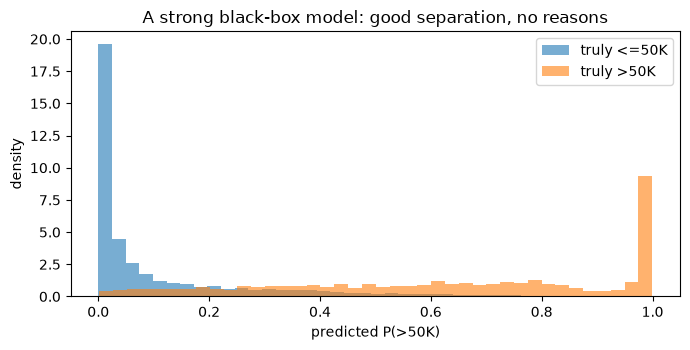

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(proba_te[y_te == 0], bins=40, alpha=0.6, label="truly <=50K", density=True)
ax.hist(proba_te[y_te == 1], bins=40, alpha=0.6, label="truly >50K", density=True)
ax.set(xlabel="predicted P(>50K)", ylabel="density", title="A strong black-box model: good separation, no reasons")
ax.legend()
plt.tight_layout()
plt.show()

**The map.** Every method in this notebook answers one of these questions:

| | **Global** — what does the model rely on? | **Local** — why this one prediction? |
|---|---|---|
| **Intrinsic** (read the model) | linear coefficients, a shallow tree's rules, EBM shape functions | the coefficients × this row's values; the tree's decision path |
| **Post-hoc, model-specific** | impurity importance, mean \|TreeSHAP\| | TreeSHAP values |
| **Post-hoc, model-agnostic** | permutation importance, PDP, mean \|SHAP\| | ICE curve, Permutation/Kernel SHAP, LIME, counterfactuals |

### ✍️ Your Turn

What share of test adults does the model flag as earning >50K at a 0.5 threshold? Store the fraction (between 0 and 1) in `share_flagged`.

In [4]:
share_flagged = None  # TODO: your code here
check("share_flagged", share_flagged, np.mean(lgbm.predict_proba(X_te)[:, 1] > 0.5), hint="np.mean(proba_te > 0.5)")

⏳ share_flagged: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
share_flagged = np.mean(proba_te > 0.5)
check("share_flagged", share_flagged, np.mean(lgbm.predict_proba(X_te)[:, 1] > 0.5))
```
Compare it with the true positive rate (~24%): a well-calibrated model flags a similar share.
</details>

> 💡 **Interview angle:** "How would you explain a model?" — first ask *to whom and for what*: a global view for model validation and feature decisions (permutation importance, mean |SHAP|, PDP), a local view for a decision a person must understand or contest (SHAP values, counterfactuals). Prefer an intrinsically interpretable model when it is nearly as accurate.

## 2. Intrinsically Interpretable Models: Coefficients and Odds Ratios 🟢

A **logistic regression** predicts log-odds as a weighted sum: $\log\frac{p}{1-p} = w_0 + \sum_j w_j x_j$. So:

- $w_j$ = change in **log-odds** when $x_j$ grows by one unit, other features fixed.
- $e^{w_j}$ = the **odds ratio**: the odds are *multiplied* by $e^{w_j}$ per unit.
- **Standardize** numeric features first; then "one unit" = one standard deviation, and magnitudes are comparable across features. A coefficient per *dollar* and one per *year of education* are not.

We one-hot encode categoricals and standardize numeric columns inside one pipeline ([04 · Logistic Regression](04_Logistic_Regression.ipynb) covers the model itself).

                coef per +1 SD  odds ratio per +1 SD  1 SD in original units
age                      0.342                 1.408                  13.735
fnlwgt                   0.075                 1.078              104960.762
education_num            0.716                 2.046                   2.574
capital_gain             2.301                 9.986                7380.966
capital_loss             0.264                 1.303                 407.014
hours_per_week           0.343                 1.409                  12.387

logistic regression test AUC 0.905 vs LightGBM 0.931 → price of a glass-box here: 0.025 AUC


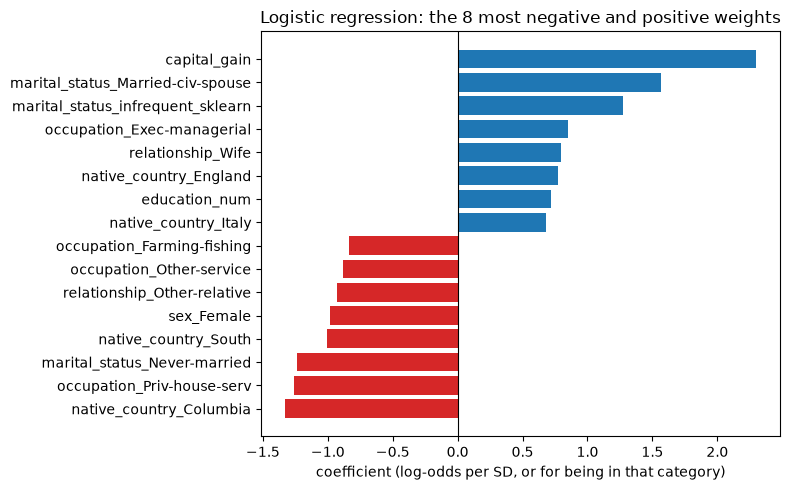

In [5]:
logit_pipe = make_pipeline(
    make_column_transformer(
        (StandardScaler(), NUM_COLS),
        (OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50, sparse_output=False), CAT_COLS),
        verbose_feature_names_out=False),
    LogisticRegression(max_iter=3000),
)
logit_pipe.fit(raw_tr[FEATURES], y_tr)
auc_logit = roc_auc_score(y_te, logit_pipe.predict_proba(raw_te[FEATURES])[:, 1])
coefs = pd.Series(logit_pipe[-1].coef_[0], index=logit_pipe[0].get_feature_names_out())
scaler_adult = logit_pipe[0].named_transformers_["standardscaler"]

numeric_view = pd.DataFrame({"coef per +1 SD": coefs[NUM_COLS], "odds ratio per +1 SD": np.exp(coefs[NUM_COLS]),
                             "1 SD in original units": scaler_adult.scale_}).round(3)
print(numeric_view.to_string())
print(f"\nlogistic regression test AUC {auc_logit:.3f} vs LightGBM {auc_lgbm:.3f} → price of a glass-box here: {auc_lgbm - auc_logit:.3f} AUC")

top = pd.concat([coefs.sort_values().head(8), coefs.sort_values().tail(8)])
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=["#d62728" if v < 0 else "#1f77b4" for v in top.values])
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="coefficient (log-odds per SD, or for being in that category)", title="Logistic regression: the 8 most negative and positive weights")
plt.tight_layout()
plt.show()

**How to read a one-hot weight:** with no dropped reference level and L2 regularization, each category's weight is relative to the *average* of its group, not to a named baseline — compare levels **within** a feature (`relationship_Wife` vs `relationship_Own-child`), not across features.

**Other glass-box models:**
- **Shallow decision trees / rule lists** — readable if-then rules ([08 · Decision Trees](08_Decision_Trees.ipynb) built a pruned rule set and `decision_path` explanations).
- **Explainable Boosting Machines (EBMs)** — a *generalized additive model* $f(x) = w_0 + \sum_j f_j(x_j) + \sum_{(i,j)} f_{ij}(x_i, x_j)$ where each shape function $f_j$ is learned by boosting tiny trees on **one feature at a time** in round-robin with a very small learning rate, plus a few detected pairwise interactions. You can plot every $f_j$ exactly, so the model *is* its explanation, often within a hair of full boosting on tabular data (library: InterpretML — described here only, not installed).

### ✍️ Your Turn

By what factor are the odds of earning >50K multiplied when `hours_per_week` increases by **10 hours** (not 1 SD)? Use `coefs` and `scaler_adult.scale_`. Store it in `odds_mult_10h`.

In [6]:
odds_mult_10h = None  # TODO: your code here
check("odds_mult_10h", odds_mult_10h, np.exp(coefs["hours_per_week"] * 10 / scaler_adult.scale_[NUM_COLS.index("hours_per_week")]),
      hint="Per original unit the coefficient is coef_per_SD / SD; for 10 units multiply by 10, then exponentiate.")

⏳ odds_mult_10h: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sd_hours = scaler_adult.scale_[NUM_COLS.index("hours_per_week")]
odds_mult_10h = np.exp(coefs["hours_per_week"] * 10 / sd_hours)
check("odds_mult_10h", odds_mult_10h, np.exp(coefs["hours_per_week"] * 10 / scaler_adult.scale_[NUM_COLS.index("hours_per_week")]))
```
Odds ratios multiply: +20 hours is the square of the +10-hour factor. That is **odds**, not probability — the probability change depends on where you start.
</details>

> 💡 **Interview angle:** "Can I rank features by the size of logistic-regression coefficients?" — only after standardizing them, and only if features aren't strongly correlated (collinearity makes weights unstable and can flip signs). Explain a weight as an odds ratio per SD, and remember a coefficient is conditional on all other features being held fixed.

## 3. Permutation Importance vs Impurity Importance 🟡

**Impurity importance** (MDI; LightGBM's `"split"` count or `"gain"`) is read from the trees: how often, or how profitably, a feature was split on **during training**. [08 · Decision Trees](08_Decision_Trees.ipynb) showed it rewards high-cardinality features that let a tree fit noise.

**Permutation importance** asks a cleaner question on **held-out** data: *if I shuffle this column — breaking its link to the target while keeping its distribution — how much does the score drop?*

```
baseline = score(model, X_valid, y_valid)
for each feature j, repeat R times:  shuffle column j  →  drop_jr = baseline − score(shuffled)
importance_j = mean_r(drop_jr)
```

**Experiment on the boosted model:** add two pure-noise columns — `random_id` (20,000 possible values) and `random_coin` (0/1) — then compare split count, gain, and permutation importance on train vs test rows.

                split count share  gain share  perm AUC drop (train)  perm AUC drop (test)  perm std (test)
capital_gain               0.0986      0.1888                 0.0609                0.0649           0.0020
age                        0.1482      0.0803                 0.0557                0.0488           0.0072
marital_status             0.0360      0.1287                 0.0295                0.0313           0.0030
education_num              0.0792      0.1513                 0.0347                0.0278           0.0018
relationship               0.0373      0.2376                 0.0167                0.0167           0.0019
hours_per_week             0.0792      0.0397                 0.0164                0.0130           0.0021
capital_loss               0.0747      0.0635                 0.0123                0.0117           0.0015
occupation                 0.0790      0.0358                 0.0131                0.0106           0.0020
sex                        0

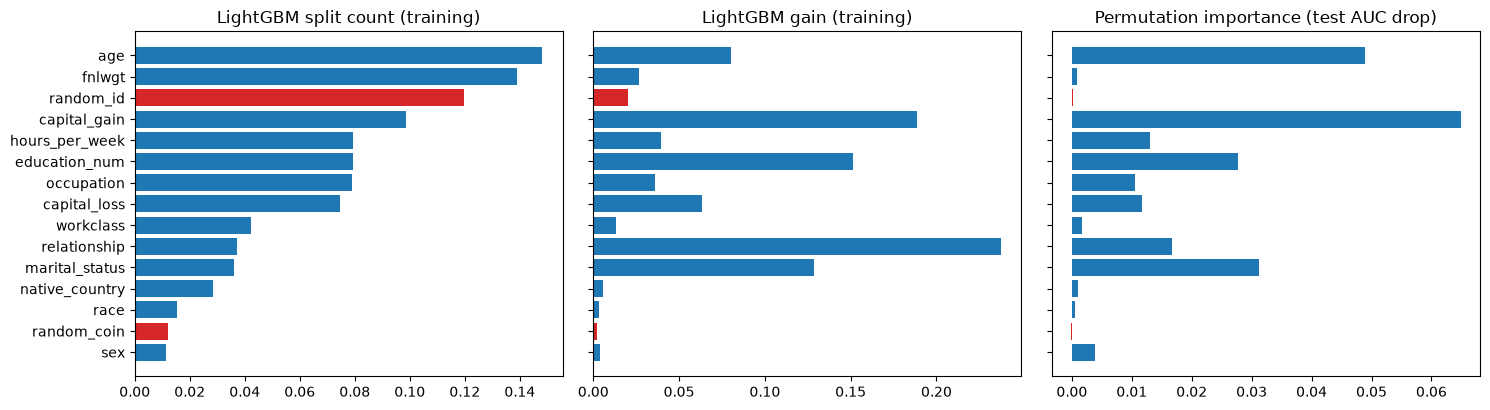

rank of random_id among 15 columns → split count: 3, gain: 10, permutation (test): 14
random_id permutation importance: train +0.0066 vs test +0.0001


In [7]:
noise_gen = np.random.default_rng(SEED)


def add_noise_columns(frame, gen):
    return frame.assign(random_id=gen.integers(0, 20_000, len(frame)).astype(float),
                        random_coin=gen.integers(0, 2, len(frame)).astype(float))


X_tr_noise, X_te_noise = add_noise_columns(X_tr, noise_gen), add_noise_columns(X_te, noise_gen)
lgbm_noise = lgb.LGBMClassifier(**LGBM_PARAMS).fit(X_tr_noise, y_tr)
noise_cols = list(X_tr_noise.columns)

te_sub = X_te_noise.iloc[:3000]
tr_sub = X_tr_noise.iloc[:3000]
perm_te = permutation_importance(lgbm_noise, te_sub, y_te[:3000], scoring="roc_auc", n_repeats=5, random_state=SEED)
perm_tr = permutation_importance(lgbm_noise, tr_sub, y_tr[:3000], scoring="roc_auc", n_repeats=5, random_state=SEED)

imp = pd.DataFrame({
    "split count share": lgbm_noise.booster_.feature_importance("split") / lgbm_noise.booster_.feature_importance("split").sum(),
    "gain share": lgbm_noise.booster_.feature_importance("gain") / lgbm_noise.booster_.feature_importance("gain").sum(),
    "perm AUC drop (train)": perm_tr.importances_mean,
    "perm AUC drop (test)": perm_te.importances_mean,
    "perm std (test)": perm_te.importances_std,
}, index=noise_cols)
print(imp.sort_values("perm AUC drop (test)", ascending=False).round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
order_idx = imp["split count share"].sort_values().index
colors = ["#d62728" if c.startswith("random") else "#1f77b4" for c in order_idx]
for ax, col, title in zip(axes, ["split count share", "gain share", "perm AUC drop (test)"],
                          ["LightGBM split count (training)", "LightGBM gain (training)", "Permutation importance (test AUC drop)"]):
    ax.barh(order_idx, imp.loc[order_idx, col], color=colors)
    ax.set(title=title)
plt.tight_layout()
plt.show()

ranks = imp.rank(ascending=False).astype(int)
print(f"rank of random_id among {len(noise_cols)} columns → split count: {ranks.loc['random_id', 'split count share']}, "
      f"gain: {ranks.loc['random_id', 'gain share']}, permutation (test): {ranks.loc['random_id', 'perm AUC drop (test)']}")
print(f"random_id permutation importance: train {imp.loc['random_id', 'perm AUC drop (train)']:+.4f} vs test {imp.loc['random_id', 'perm AUC drop (test)']:+.4f}")

Split counts love `random_id` and `fnlwgt` (a census sampling weight with ~28,000 distinct values): many distinct values → many chances to find a split that helps on the training rows. On **test** data, shuffling noise costs nothing. On **training** rows, even permutation importance gives noise some credit, because the model memorized it — always compute it on data the model has not seen.

### ✍️ Your Turn

How many **real** features (not `random_id` / `random_coin`) have a larger test permutation importance than `random_id`? Store the integer in `n_real_above_noise`.

In [8]:
n_real_above_noise = None  # TODO: your code here
_real = imp.drop(index=["random_id", "random_coin"])
check("n_real_above_noise", n_real_above_noise, int((_real["perm AUC drop (test)"] > imp.loc["random_id", "perm AUC drop (test)"]).sum()),
      hint="Drop the two random rows from imp, compare its 'perm AUC drop (test)' column with random_id's value, sum the booleans.")

⏳ n_real_above_noise: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
real_features = imp.drop(index=["random_id", "random_coin"])
n_real_above_noise = int((real_features["perm AUC drop (test)"] > imp.loc["random_id", "perm AUC drop (test)"]).sum())
_real = imp.drop(index=["random_id", "random_coin"])
check("n_real_above_noise", n_real_above_noise, int((_real["perm AUC drop (test)"] > imp.loc["random_id", "perm AUC drop (test)"]).sum()))
```
Adding a random column and keeping only features that beat it is a cheap, honest feature-selection baseline (sometimes called "shadow features", as in Boruta).
</details>

> 💡 **Interview angle:** "Why can't I trust `feature_importances_`?" — split/gain importance is computed on training data and favours continuous or high-cardinality features that offer many split points, even pure noise (our random ID). Permutation importance on a held-out set measures the actual loss in score; report its spread over repeats, and remember it measures what *this model* uses, not what is causally important.

## 4. Correlated Features: Split Credit and Grouped Permutation 🔴

**Assumption behind permutation importance:** shuffling one column produces realistic rows. When two features carry the same information, that breaks: the model can fall back on the twin, so each looks unimportant even though **the pair** is essential.

Adult has a real pair of twins: `education` (text, 16 levels, here coded alphabetically) and `education_num` (1–16) are the **same information** coded twice. We add `education` back and train twin models under two common settings — every feature available to every tree (LightGBM's default), and `colsample_bytree=0.5` (each tree sees a random half of the features, a popular regularizer) — and compare each with a model that only has `education_num`.

each education name maps to exactly one education_num: True


                                           default (all features per tree)  colsample_bytree=0.5
single model — perm(education_num)                                  0.0296                0.0268
twin model — perm(education_num)                                    0.0291                0.0157
twin model — perm(education)                                        0.0003                0.0010
twin model — sum of the two                                         0.0294                0.0167
twin model — perm(both shuffled together)                           0.0287                0.0282
single model — mean|SHAP|(education_num)                            0.4796                0.4933
twin model — mean|SHAP|(education_num)                              0.4732                0.4010
twin model — mean|SHAP|(education)                                  0.0181                0.1039

default (all features per tree): education_num keeps 98% of its importance; the copy gets 4% of the pair's SHAP credit; sum of

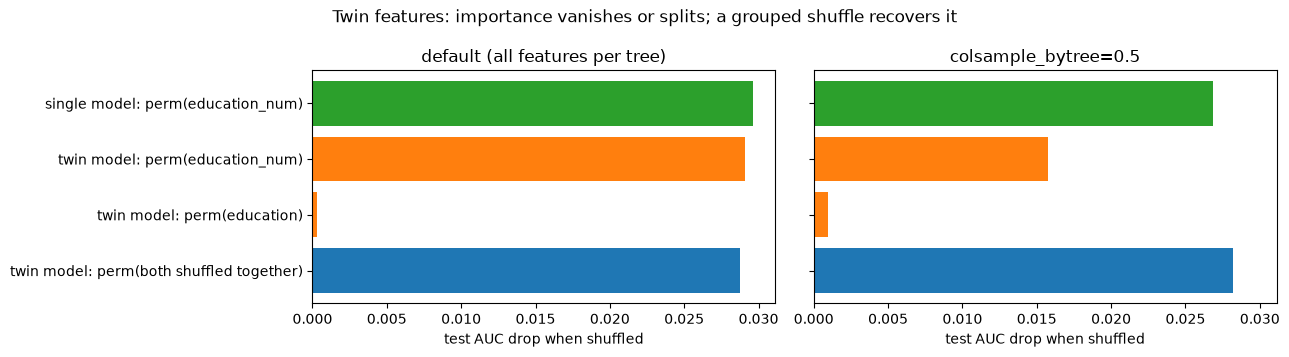

In [9]:
levels_per_name = pd.crosstab(adult_raw["education"], adult_raw["education_num"]).gt(0).sum(axis=1)
print(f"each education name maps to exactly one education_num: {bool((levels_per_name == 1).all())}")

X_tr_twin = X_tr.assign(education=X_all.loc[idx_tr, "education"])
X_te_twin = X_te.assign(education=X_all.loc[idx_te, "education"])
TWIN_COLS = list(X_tr_twin.columns)


def grouped_permutation_importance(model, X, y, groups, n_repeats=5, seed=0, scoring="roc_auc"):
    """Shuffle every column of a group with the SAME row permutation, so the group's joint values stay realistic."""
    scorer = get_scorer(scoring)
    baseline = scorer(model, X, y)
    gen = np.random.default_rng(seed)
    result = {}
    for name, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            order = gen.permutation(len(X))
            X_perm[cols] = X[cols].to_numpy()[order]
            drops.append(baseline - scorer(model, X_perm, y))
        result[name] = float(np.mean(drops))
    return pd.Series(result)


rows_single, rows_twin = X_te.iloc[:3000], X_te_twin.iloc[:3000]
y_rows = y_te[:3000]
twin_groups = {"education_num": ["education_num"], "education": ["education"], "group": ["education_num", "education"]}
twin_records = {}
for setting, extra in [("default (all features per tree)", {}), ("colsample_bytree=0.5", {"colsample_bytree": 0.5})]:
    single_model = lgbm if not extra else lgb.LGBMClassifier(**LGBM_PARAMS, **extra).fit(X_tr, y_tr)
    twin_model = lgb.LGBMClassifier(**LGBM_PARAMS, **extra).fit(X_tr_twin, y_tr)
    single_drop = grouped_permutation_importance(single_model, rows_single, y_rows, {"education_num": ["education_num"]})["education_num"]
    twin_drop = grouped_permutation_importance(twin_model, rows_twin, y_rows, twin_groups)
    shap_single = np.abs(shap.TreeExplainer(single_model)(rows_single.iloc[:1000]).values).mean(axis=0)
    shap_twin = np.abs(shap.TreeExplainer(twin_model)(rows_twin.iloc[:1000]).values).mean(axis=0)
    twin_records[setting] = {
        "single model — perm(education_num)": single_drop,
        "twin model — perm(education_num)": twin_drop["education_num"],
        "twin model — perm(education)": twin_drop["education"],
        "twin model — sum of the two": twin_drop["education_num"] + twin_drop["education"],
        "twin model — perm(both shuffled together)": twin_drop["group"],
        "single model — mean|SHAP|(education_num)": shap_single[FEATURES.index("education_num")],
        "twin model — mean|SHAP|(education_num)": shap_twin[TWIN_COLS.index("education_num")],
        "twin model — mean|SHAP|(education)": shap_twin[TWIN_COLS.index("education")],
    }
twin_table = pd.DataFrame(twin_records)
print(twin_table.round(4).to_string())

for setting, rec in twin_records.items():
    kept = rec["twin model — perm(education_num)"] / rec["single model — perm(education_num)"]
    copy_share = rec["twin model — mean|SHAP|(education)"] / (rec["twin model — mean|SHAP|(education)"] + rec["twin model — mean|SHAP|(education_num)"])
    print(f"\n{setting}: education_num keeps {kept:.0%} of its importance; the copy gets {copy_share:.0%} of the pair's SHAP credit; "
          f"sum of single-column drops {rec['twin model — sum of the two']:.4f} vs grouped drop {rec['twin model — perm(both shuffled together)']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharex=True)
bar_keys = ["single model — perm(education_num)", "twin model — perm(education_num)", "twin model — perm(education)", "twin model — perm(both shuffled together)"]
for ax, (setting, rec) in zip(axes, twin_records.items()):
    ax.barh([k.replace(" — ", ": ") for k in bar_keys][::-1], [rec[k] for k in bar_keys][::-1], color=["#1f77b4", "#ff7f0e", "#ff7f0e", "#2ca02c"])
    ax.set(xlabel="test AUC drop when shuffled", title=setting)
axes[1].set_yticklabels([])
fig.suptitle("Twin features: importance vanishes or splits; a grouped shuffle recovers it")
plt.tight_layout()
plt.show()

What the table shows: with **all features per tree**, LightGBM simply prefers the ordered `education_num` and almost ignores the alphabetical copy — the copy's importance **vanishes** (a *retrained* model without `education_num` would happily use it, so "unimportant" is wrong). With **feature subsampling**, trees that don't see `education_num` use the copy instead, so the importance **splits**: each twin alone drops less than the original, and the two single-column drops add up to much less than shuffling the pair together. **SHAP** splits the credit the same way — it cannot know the columns are the same thing. Fixes: **group** correlated or one-hot columns and permute them together (above), drop or merge duplicates, or use conditional importance methods. scikit-learn's docs cluster features by Spearman correlation and keep one per cluster (see Resources).

### ✍️ Your Turn

`relationship` and `marital_status` overlap heavily ("Husband" implies "Married-civ-spouse"). Using `grouped_permutation_importance` on `lgbm` with `rows_single`/`y_rows`, compute the importance of the **group** `["relationship", "marital_status"]` and store it in `family_group_drop` (use the default `n_repeats=5, seed=0`).

In [10]:
family_group_drop = None  # TODO: your code here
check("family_group_drop", family_group_drop,
      grouped_permutation_importance(lgbm, rows_single, y_rows, {"family": ["relationship", "marital_status"]})["family"],
      hint="grouped_permutation_importance(lgbm, rows_single, y_rows, {'family': [...]})['family']")

⏳ family_group_drop: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
family = grouped_permutation_importance(lgbm, rows_single, y_rows, {"family": ["relationship", "marital_status"],
                                                                   "relationship": ["relationship"], "marital_status": ["marital_status"]})
family_group_drop = family["family"]
print(family.round(4))
check("family_group_drop", family_group_drop,
      grouped_permutation_importance(lgbm, rows_single, y_rows, {"family": ["relationship", "marital_status"]})["family"])
```
Compare the group's drop with each member's: the group is worth more than either alone, but less than their sum would suggest after correlation is taken into account.
</details>

> 💡 **Interview angle:** "Two features are 95% correlated. What happens to their importance?" — the model can use either, so permutation importance of each drops (the twin compensates) and a drop-one-feature retrain shows almost nothing; SHAP and impurity importance split the credit arbitrarily between them. Report grouped importance, or de-duplicate/cluster features first. Never conclude "feature X is useless" from one low importance when it has a correlated partner.

## 5. Partial Dependence and ICE Plots 🟡

Importance says **how much**; partial dependence says **how**: does the prediction rise, fall, saturate, or jump?

- **ICE (Individual Conditional Expectation):** take one row, sweep one feature over a grid, keep everything else fixed, and plot the model's prediction — one curve per row.
- **PDP (Partial Dependence Plot):** the average of all ICE curves: $\text{PD}_j(v) = \frac1n\sum_i f(x_{i,1},\dots, x_{i,j}=v, \dots)$.

If ICE curves are parallel, the PDP tells the whole story; if they cross or fan out, the feature **interacts** with others and the average hides it. We switch to **California housing** (20,640 real districts; **target:** median house value in $100k) with a `HistGradientBoostingRegressor`.

HistGradientBoosting on California housing: test R² 0.852


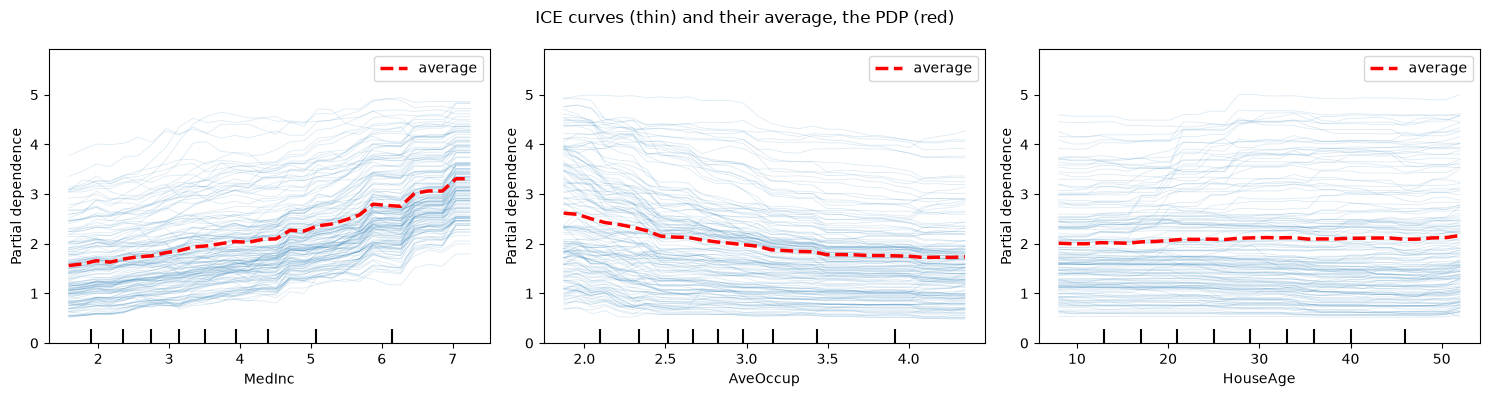

In [11]:
housing = fetch_california_housing(as_frame=True, data_home=DATA_HOME)
X_ca, y_ca = housing.data, housing.target
X_ca_tr, X_ca_te, y_ca_tr, y_ca_te = train_test_split(X_ca, y_ca, test_size=0.25, random_state=SEED)
hgb_ca = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.1, random_state=0).fit(X_ca_tr, y_ca_tr)
print(f"HistGradientBoosting on California housing: test R² {hgb_ca.score(X_ca_te, y_ca_te):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(hgb_ca, X_ca_te, ["MedInc", "AveOccup", "HouseAge"], kind="both", subsample=150,
                                        grid_resolution=30, random_state=0, ax=axes,
                                        ice_lines_kw={"alpha": 0.15, "linewidth": 0.6}, pd_line_kw={"color": "red", "linewidth": 2.5})
fig.suptitle("ICE curves (thin) and their average, the PDP (red)")
plt.tight_layout()
plt.show()

**Reading it:** value rises with median income and saturates at the top (the dataset caps values at $500k); high occupancy lowers value; `HouseAge` has a mild effect but the ICE curves are spread vertically — a district's *level* depends on other features. `centered=True` subtracts each curve's starting value, which makes differences in *shape* (interactions) easier to see.

A **2-D PDP** shows how two features combine. With longitude and latitude the model's learned price map of California appears:

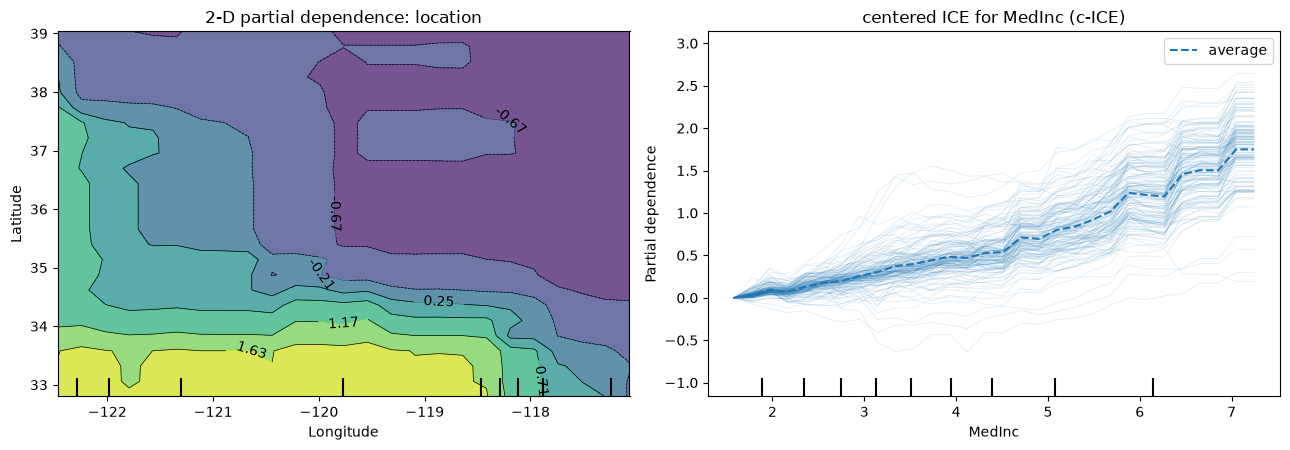

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
PartialDependenceDisplay.from_estimator(hgb_ca, X_ca_te.iloc[:2000], [("Longitude", "Latitude")], kind="average",
                                        grid_resolution=25, ax=axes[0])
axes[0].set_title("2-D partial dependence: location")
PartialDependenceDisplay.from_estimator(hgb_ca, X_ca_te, ["MedInc"], kind="both", centered=True, subsample=150,
                                        grid_resolution=30, random_state=0, ax=axes[1], ice_lines_kw={"alpha": 0.15})
axes[1].set_title("centered ICE for MedInc (c-ICE)")
plt.tight_layout()
plt.show()

### When the PDP lies: correlated features

To draw a PDP for `Latitude`, scikit-learn sets **every** district's latitude to each grid value while keeping its real longitude. But latitude and longitude are strongly tied in California's shape — so many of those synthetic districts sit in the Pacific Ocean or in Nevada, where the model never saw data and its predictions are arbitrary. Let's count them.

corr(Latitude, Longitude) = -0.92; corr(AveRooms, AveBedrms) = 0.85
synthetic PDP points with no real district within 0.3°: 39.0% (real districts: 0.0%)


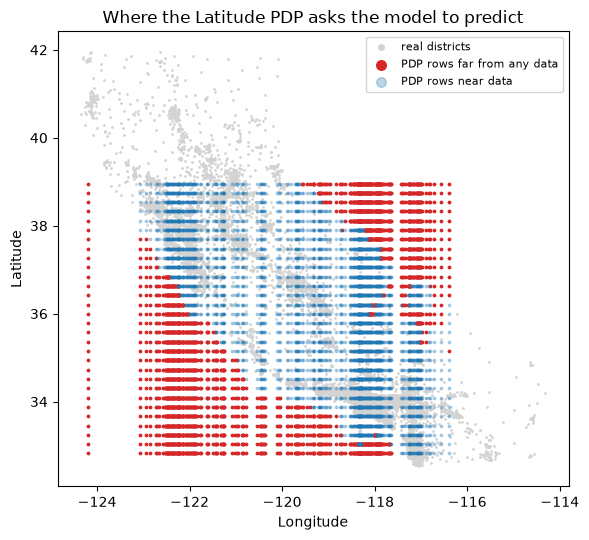

In [13]:
pdp_rows = X_ca_te.sample(300, random_state=0)
lat_grid = np.linspace(X_ca["Latitude"].quantile(0.05), X_ca["Latitude"].quantile(0.95), 30)
synthetic = np.array([[lat, lon] for lat in lat_grid for lon in pdp_rows["Longitude"]])
geo_tree = KDTree(X_ca[["Latitude", "Longitude"]].to_numpy())
dist_synthetic = geo_tree.query(synthetic, k=1)[0].ravel()
dist_real = geo_tree.query(pdp_rows[["Latitude", "Longitude"]].to_numpy(), k=2)[0][:, 1]     # nearest *other* district
FAR = 0.3                                                                                     # degrees ≈ 30 km
print(f"corr(Latitude, Longitude) = {X_ca['Latitude'].corr(X_ca['Longitude']):.2f}; corr(AveRooms, AveBedrms) = {X_ca['AveRooms'].corr(X_ca['AveBedrms']):.2f}")
print(f"synthetic PDP points with no real district within {FAR}°: {np.mean(dist_synthetic > FAR):.1%} "
      f"(real districts: {np.mean(dist_real > FAR):.1%})")

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(X_ca["Longitude"], X_ca["Latitude"], s=1, color="lightgray", label="real districts")
far_mask = dist_synthetic > FAR
ax.scatter(synthetic[far_mask, 1], synthetic[far_mask, 0], s=3, color="#d62728", label="PDP rows far from any data")
ax.scatter(synthetic[~far_mask, 1], synthetic[~far_mask, 0], s=3, color="#1f77b4", alpha=0.3, label="PDP rows near data")
ax.set(xlabel="Longitude", ylabel="Latitude", title="Where the Latitude PDP asks the model to predict")
ax.legend(markerscale=4, fontsize=8)
plt.tight_layout()
plt.show()

**The fix — ALE (Accumulated Local Effects), in words:** split the feature into quantile bins; *within each bin*, use only the rows that really fall in it, and measure how predictions change when the feature moves from the bin's lower to upper edge; accumulate those local differences. Because each row only moves a little, within its own neighbourhood, ALE never invents ocean districts. ALE plots are available in packages such as `alibi` and `PyALE` (not installed here); Molnar's book (Resources) has the details. SHAP scatter plots (section 8) are another view that only uses real rows.

### ✍️ Your Turn

Compute one point of a partial dependence curve **by hand**. `pd_medinc` below holds scikit-learn's PDP for `MedInc` on 500 test rows. Set `MedInc` of every row in `X_pd` to the grid value `pd_medinc["grid_values"][0][3]`, predict, and average. Store the number in `pd_by_hand`.

In [14]:
X_pd = X_ca_te.sample(500, random_state=1)
pd_medinc = partial_dependence(hgb_ca, X_pd, ["MedInc"], kind="average", grid_resolution=10, method="brute")
print("grid:", pd_medinc["grid_values"][0].round(2))
print("PD:  ", pd_medinc["average"][0].round(3))

grid: [1.49 2.12 2.75 3.39 4.02 4.65 5.28 5.91 6.54 7.17]
PD:   [1.55  1.648 1.764 1.922 2.044 2.26  2.409 2.815 3.051 3.331]


In [15]:
pd_by_hand = None  # TODO: your code here
check("pd_by_hand", pd_by_hand, pd_medinc["average"][0][3], hint="X_mod = X_pd.assign(MedInc=grid_value); hgb_ca.predict(X_mod).mean()")

⏳ pd_by_hand: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
grid_value = pd_medinc["grid_values"][0][3]
pd_by_hand = hgb_ca.predict(X_pd.assign(MedInc=grid_value)).mean()
check("pd_by_hand", pd_by_hand, pd_medinc["average"][0][3])
```
That's the whole algorithm ("brute" method). For some tree models scikit-learn has a faster `method="recursion"` that walks the trees instead of predicting.
</details>

> 💡 **Interview angle:** "What's the difference between a PDP and an ICE plot, and when does a PDP mislead?" — ICE draws one what-if curve per row; the PDP averages them. The PDP hides heterogeneous effects (look at ICE) and, with correlated features, averages predictions on unrealistic combinations (here ocean districts) — use ALE or conditional methods instead.

## 6. Shapley Values: Fair Credit From Game Theory 🟡

Lloyd Shapley (Nobel prize, 2012) asked: *players cooperate and earn a payout; how do we split it fairly?* The **Shapley value** of player $j$ is their marginal contribution $v(S\cup\{j\}) - v(S)$, averaged over **every order** in which the team could have assembled:

$$\phi_j = \sum_{S \subseteq N\setminus\{j\}} \frac{\lvert S\rvert!\,(M-\lvert S\rvert-1)!}{M!}\,\big[v(S\cup\{j\}) - v(S)\big]$$

The weight is just "the fraction of orderings in which exactly the players in $S$ arrive before $j$".

**The four axioms** (the Shapley value is the *only* attribution satisfying all four):
1. **Efficiency** — the shares add up to the total: $\sum_j \phi_j = v(N) - v(\varnothing)$.
2. **Symmetry** — two players who contribute identically to every coalition get the same share.
3. **Dummy (null player)** — a player who never changes any coalition's payout gets 0.
4. **Additivity** — for a game that is the sum of two games, shares add (e.g. a model that averages trees: explain each tree and add).

**For a model:** players = features; payout of a coalition $S$ = the model's expected output when we only "know" the features in $S$. In the **interventional** version, unknown features are filled from a **background** dataset: $v(S) = \frac{1}{|B|}\sum_{b\in B} f(x_S, b_{\bar S})$. Then $v(\varnothing)$ is the average prediction and $v(N)=f(x)$.

Let's compute exact Shapley values for a tiny model: a depth-4 tree on **3** California features, so there are only $2^3 = 8$ coalitions to evaluate.

x* = {'MedInc': 1.681, 'AveOccup': 3.877, 'HouseAge': 25.0}
  v({}) = 1.9864
  v({MedInc}) = 1.1492
  v({AveOccup}) = 1.8325
  v({HouseAge}) = 1.9971
  v({MedInc, AveOccup}) = 1.0930
  v({MedInc, HouseAge}) = 1.1492
  v({AveOccup, HouseAge}) = 1.8209
  v({MedInc, AveOccup, HouseAge}) = 1.0930

Shapley values: {'MedInc': -0.7863, 'AveOccup': -0.1088, 'HouseAge': 0.0016}
efficiency: sum = -0.893386 | f(x*) − E[f] = -0.893386


✅ matches shap.explainers.Exact: [-0.7863 -0.1088  0.0016] (base value 1.9864)


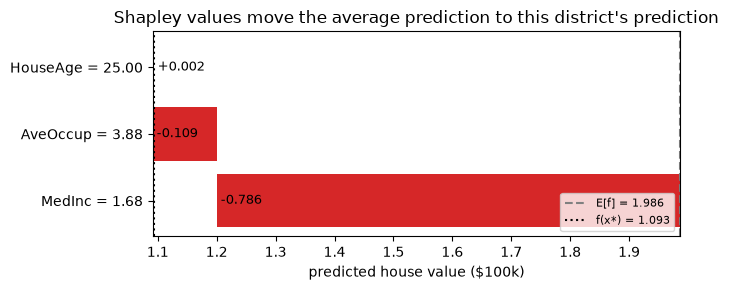

In [16]:
three = ["MedInc", "AveOccup", "HouseAge"]
tiny_model = DecisionTreeRegressor(max_depth=4, random_state=0).fit(X_ca_tr[three], y_ca_tr)
background_ca = X_ca_tr[three].sample(200, random_state=SEED)
x_star = X_ca_te[three].iloc[0]


def coalition_value(model, x, background, coalition, columns):
    """v(S): average prediction when features in S take x's values and the rest come from the background rows."""
    data = background.copy()
    for col in coalition:
        data[col] = x[col]
    return model.predict(data[columns]).mean()


coalitions = [c for k in range(len(three) + 1) for c in itertools.combinations(three, k)]
v = {frozenset(c): coalition_value(tiny_model, x_star, background_ca, c, three) for c in coalitions}
print("x* =", x_star.round(3).to_dict())
for c in coalitions:
    print(f"  v({{{', '.join(c)}}}) = {v[frozenset(c)]:.4f}")

M = len(three)
phi_tiny = {}
for feat in three:
    others = [f for f in three if f != feat]
    total = 0.0
    for k in range(M):
        for S in itertools.combinations(others, k):
            weight = math.factorial(k) * math.factorial(M - k - 1) / math.factorial(M)
            total += weight * (v[frozenset(S) | {feat}] - v[frozenset(S)])
    phi_tiny[feat] = total
print("\nShapley values:", {k: round(float(val), 4) for k, val in phi_tiny.items()})
print(f"efficiency: sum = {sum(phi_tiny.values()):.6f} | f(x*) − E[f] = {tiny_model.predict(x_star.to_frame().T)[0] - v[frozenset()]:.6f}")

exact_tiny = shap.explainers.Exact(lambda A: tiny_model.predict(pd.DataFrame(A, columns=three)),
                                   shap.maskers.Independent(background_ca, max_samples=len(background_ca)))
sv_tiny = exact_tiny(X_ca_te[three].iloc[[0]], silent=True)
assert np.allclose(sv_tiny.values[0], [phi_tiny[f] for f in three])
print(f"✅ matches shap.explainers.Exact: {sv_tiny.values[0].round(4)} (base value {sv_tiny.base_values[0]:.4f})")

fig, ax = plt.subplots(figsize=(7, 3))
running = v[frozenset()]
for i, feat in enumerate(three):
    ax.barh(i, phi_tiny[feat], left=running, color="#1f77b4" if phi_tiny[feat] > 0 else "#d62728")
    ax.text(running + phi_tiny[feat], i, f" {phi_tiny[feat]:+.3f}", va="center", fontsize=9)
    running += phi_tiny[feat]
ax.axvline(v[frozenset()], color="gray", ls="--", label=f"E[f] = {v[frozenset()]:.3f}")
ax.axvline(running, color="k", ls=":", label=f"f(x*) = {running:.3f}")
ax.set_yticks(range(M), [f"{f} = {x_star[f]:.2f}" for f in three])
ax.set(xlabel="predicted house value ($100k)", title="Shapley values move the average prediction to this district's prediction")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

Exact computation needs $2^M$ coalitions × background rows: 8 features → 256, 13 → 8,192, 50 → $10^{15}$. That's why SHAP has fast special cases (trees, linear models) and sampling approximations for everything else.

### ✍️ Your Turn

Two players: $v(\varnothing)=0$, $v(\{A\})=10$, $v(\{B\})=20$, $v(\{A,B\})=50$. Compute player A's Shapley value (average A's marginal contribution over the two orderings A→B and B→A) and store it in `phi_A`.

In [17]:
phi_A = None  # TODO: your code here
check("phi_A", phi_A, 20.0, hint="Order A→B: A adds v(A) − v(∅); order B→A: A adds v(AB) − v(B). Average the two.")

⏳ phi_A: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
phi_A = 0.5 * (10 - 0) + 0.5 * (50 - 20)
check("phi_A", phi_A, 20.0)
```
B gets $0.5(20-0) + 0.5(50-10) = 30$, and $20 + 30 = 50 = v(AB) - v(\varnothing)$ — efficiency. The +20 of "synergy" is split equally, which is exactly how SHAP splits **interaction** effects between features.
</details>

> 💡 **Interview angle:** "What is a Shapley value, intuitively?" — a feature's marginal contribution to the prediction, averaged over every order of adding features, where "absent" features are filled in from background data. It is the unique attribution with efficiency (contributions sum to prediction minus average), symmetry, dummy, and additivity — which is why SHAP values always add up exactly.

## 7. TreeSHAP: Exact, Fast, and Additive in Log-Odds 🔴

**SHAP** (SHapley Additive exPlanations, Lundberg & Lee 2017) applies Shapley values to models with a guarantee called **local accuracy**:

$$f(x) = \phi_0 + \sum_{j=1}^{M} \phi_j(x), \qquad \phi_0 = \text{base value} = \text{average model output}$$

**Which output?** For a LightGBM/XGBoost classifier, TreeSHAP explains the **raw margin — the log-odds** — because trees add up in log-odds space. So SHAP values are in log-odds units, and $P(\text{>50K}) = \sigma(\phi_0 + \sum_j\phi_j)$.

**TreeSHAP** (Lundberg et al. 2020) computes exact Shapley values for trees in polynomial time by pushing all coalitions through each tree at once. It has two ways to define "a feature is absent":

| `feature_perturbation` | "Absent" feature means… | Needs background data? | Cost | Notes |
|---|---|---|---|---|
| `"tree_path_dependent"` (default when no data is passed) | follow both branches, weighted by how many **training** rows went each way | no — uses node cover stored in the trees | $O(TLD^2)$ per row ($T$ trees, $L$ leaves, depth $D$) | fast; approximates the *conditional* expectation along tree paths |
| `"interventional"` | replace by values from a background dataset (breaks correlations, like section 6) | yes (≈100–1,000 rows) | $O(TLB)$ per row ($B$ background rows) | the "causal-intervention on the model's inputs" view; lets you explain probability or log loss |

In [18]:
tree_explainer = shap.TreeExplainer(lgbm)
start = time.perf_counter()
sv = tree_explainer(X_explain)
t_path = time.perf_counter() - start
margin = lgbm.predict(X_explain, raw_score=True)
additivity_error = np.abs(sv.base_values + sv.values.sum(axis=1) - margin).max()
print(f"feature_perturbation used: {tree_explainer.feature_perturbation} | SHAP values shape {sv.values.shape} | {t_path:.2f}s for {len(X_explain):,} rows")
print(f"base value (log-odds) {sv.base_values[0]:.4f} → as a probability {sigmoid(sv.base_values[0]):.3f}")
print(f"additivity: max |base + Σ SHAP − raw margin| over {len(X_explain):,} rows = {additivity_error:.2e}")

row = 0
logit_row = sv.base_values[row] + sv.values[row].sum()
print(f"\nrow {row}: base {sv.base_values[row]:+.3f} + Σ SHAP {sv.values[row].sum():+.3f} = {logit_row:+.3f} log-odds "
      f"→ σ(·) = {sigmoid(logit_row):.4f} | predict_proba = {lgbm.predict_proba(X_explain.iloc[[row]])[0, 1]:.4f}")
assert additivity_error < 1e-6 and np.isclose(sigmoid(logit_row), lgbm.predict_proba(X_explain.iloc[[row]])[0, 1])

feature_perturbation used: tree_path_dependent | SHAP values shape (2000, 13) | 0.08s for 2,000 rows
base value (log-odds) -2.3351 → as a probability 0.088
additivity: max |base + Σ SHAP − raw margin| over 2,000 rows = 3.02e-14

row 0: base -2.335 + Σ SHAP +1.562 = -0.773 log-odds → σ(·) = 0.3158 | predict_proba = 0.3158


**Interventional vs path-dependent**, on the same rows, with 100 background rows from the training set. We also ask for SHAP values of the **probability** (`model_output="probability"`, interventional only) — then the values add up to the probability instead of the log-odds.

In [19]:
background_adult = X_tr.sample(100, random_state=SEED)
interv_explainer = shap.TreeExplainer(lgbm, data=background_adult, feature_perturbation="interventional")
start = time.perf_counter()
sv_int = interv_explainer(X_explain.iloc[:500])
t_int = time.perf_counter() - start
diff = np.abs(sv_int.values - sv.values[:500])
glob_path, glob_int = np.abs(sv.values[:500]).mean(axis=0), np.abs(sv_int.values).mean(axis=0)
print(f"interventional: {t_int:.2f}s for 500 rows ({t_int / 500 * 1000:.2f} ms/row) vs path-dependent {t_path / len(X_explain) * 1000:.3f} ms/row")
print(f"base values: interventional {sv_int.base_values[0]:.4f} (mean margin on background {lgbm.predict(background_adult, raw_score=True).mean():.4f}) "
      f"vs path-dependent {sv.base_values[0]:.4f}")
print(f"per-value mean |difference| {diff.mean():.4f} log-odds (typical |SHAP| {np.abs(sv.values).mean():.4f}); "
      f"global rankings Spearman ρ = {spearmanr(glob_path, glob_int).statistic:.3f}")

prob_explainer = shap.TreeExplainer(lgbm, data=background_adult, feature_perturbation="interventional", model_output="probability")
sv_prob = prob_explainer(X_explain.iloc[:200])
prob_err = np.abs(sv_prob.base_values + sv_prob.values.sum(axis=1) - lgbm.predict_proba(X_explain.iloc[:200])[:, 1]).max()
print(f"probability-scale SHAP: base {sv_prob.base_values[0]:.3f}, additivity error in probability {prob_err:.1e}")

interventional: 1.75s for 500 rows (3.51 ms/row) vs path-dependent 0.040 ms/row
base values: interventional -2.6926 (mean margin on background -2.6926) vs path-dependent -2.3351
per-value mean |difference| 0.0516 log-odds (typical |SHAP| 0.3309); global rankings Spearman ρ = 0.989


probability-scale SHAP: base 0.221, additivity error in probability 1.5e-08


**Keep the additivity check on.** `shap` verifies $\phi_0 + \sum\phi = f(x)$ by default and raises when it fails — which does happen with some model/version combinations. In our tests with shap 0.52, *interventional* TreeSHAP on scikit-learn's `HistGradientBoostingRegressor` fails this check (path-dependent works), so we use LightGBM wherever we need interventional values:

In [20]:
try:
    shap.TreeExplainer(hgb_ca, data=X_ca_tr.sample(100, random_state=0), feature_perturbation="interventional")(X_ca_te.iloc[:20])
    print("interventional TreeSHAP on HistGradientBoostingRegressor passed the additivity check in this version")
except Exception as err:                                              # shap raises ExplainerError here
    print(f"⚠️ {type(err).__name__}: {str(err)[:120]}…")
print(f"path-dependent on the same model: {shap.TreeExplainer(hgb_ca)(X_ca_te.iloc[:20]).values.shape} ✅")

⚠️ ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape th…
path-dependent on the same model: (20, 8) ✅


**SHAP interaction values** split each SHAP value further into a main effect (diagonal) and pairwise interaction effects (off-diagonal, split half-half between the pair): $\phi_j = \phi_{jj} + \sum_{k\ne j}\phi_{jk}$. They cost roughly $M$ times more.

In [21]:
start = time.perf_counter()
inter = tree_explainer.shap_interaction_values(X_explain.iloc[:300])
t_inter = time.perf_counter() - start
print(f"interaction values shape {inter.shape} in {t_inter:.2f}s | rows of the matrix sum to SHAP values: "
      f"{np.allclose(inter.sum(axis=2), sv.values[:300], atol=1e-6)}")
mean_inter = np.abs(inter).mean(axis=0)
off_diag = mean_inter.copy()
np.fill_diagonal(off_diag, 0)
i_top, j_top = np.unravel_index(np.argmax(off_diag), off_diag.shape)
main_share = np.trace(mean_inter) / mean_inter.sum()
print(f"strongest interaction: {FEATURES[i_top]} × {FEATURES[j_top]} (mean |φ_ij| {off_diag[i_top, j_top]:.4f}); "
      f"main effects hold {main_share:.0%} of total |interaction-matrix| mass")

timing = pd.DataFrame({"method": ["TreeSHAP path-dependent", "TreeSHAP interventional (B=100)", "SHAP interaction values"],
                       "ms per row": [t_path / len(X_explain) * 1000, t_int / 500 * 1000, t_inter / 300 * 1000]}).round(3)
print(timing.to_string(index=False))

interaction values shape (300, 13, 13) in 2.24s | rows of the matrix sum to SHAP values: True
strongest interaction: age × marital_status (mean |φ_ij| 0.0787); main effects hold 68% of total |interaction-matrix| mass
                         method  ms per row
        TreeSHAP path-dependent       0.040
TreeSHAP interventional (B=100)       3.506
        SHAP interaction values       7.456


### ✍️ Your Turn

Using `sv` only (no `predict_proba`), compute the model's predicted probability for row 5 of `X_explain`. Store it in `proba_row5`.

In [22]:
proba_row5 = None  # TODO: your code here
check("proba_row5", proba_row5, lgbm.predict_proba(X_explain.iloc[[5]])[0, 1], hint="sigmoid(base value + sum of the row's SHAP values)")

⏳ proba_row5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
proba_row5 = sigmoid(sv.base_values[5] + sv.values[5].sum())
check("proba_row5", proba_row5, lgbm.predict_proba(X_explain.iloc[[5]])[0, 1])
```
Add in log-odds, convert **once** at the end. Adding up per-feature *probability* changes computed separately would not reproduce the prediction (Pitfall 5).
</details>

> 💡 **Interview angle:** "What exactly does TreeSHAP explain for a gradient-boosted classifier?" — the raw log-odds margin: base value (average margin) plus SHAP values equals the model's log-odds exactly, and the probability is the sigmoid of that sum. Path-dependent TreeSHAP needs no background data and costs $O(TLD^2)$ per row; interventional TreeSHAP uses a background set, breaks feature correlations, and can explain the probability directly.

## 8. Reading SHAP Plots: Waterfall, Beeswarm, Bar, Scatter 🟢

| Plot | Scope | Question it answers |
|---|---|---|
| **Waterfall** | one row | which features pushed *this* prediction up or down from the base value, and by how much? |
| **Beeswarm** | all rows | which features matter most, and does a high feature value push up or down? |
| **Bar** | all rows | global importance = mean \|SHAP value\| |
| **Scatter (dependence)** | one feature | how does the SHAP value change with the feature's value, and which other feature colours the vertical spread (interaction)? |

For the waterfall we attach the original category text (`display_data`), so the labels read `occupation = Exec-managerial` instead of a code.

waterfall for row 536: P(>50K) = 0.700 (units below are log-odds)


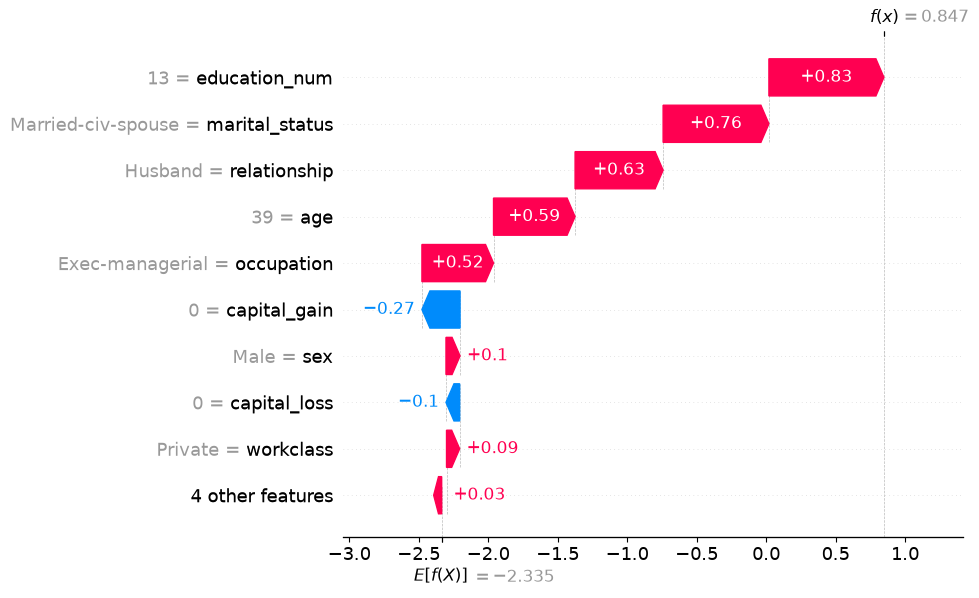

In [23]:
sv_display = shap.Explanation(values=sv.values, base_values=sv.base_values, data=sv.data, feature_names=FEATURES,
                              display_data=raw_te.loc[X_explain.index, FEATURES].to_numpy())
row_id = int(np.argmin(np.abs(lgbm.predict_proba(X_explain)[:, 1] - 0.7)))     # a person scored at about 70%
print(f"waterfall for row {row_id}: P(>50K) = {lgbm.predict_proba(X_explain.iloc[[row_id]])[0, 1]:.3f} (units below are log-odds)")
shap.plots.waterfall(sv_display[row_id], max_display=10, show=False)
plt.show()

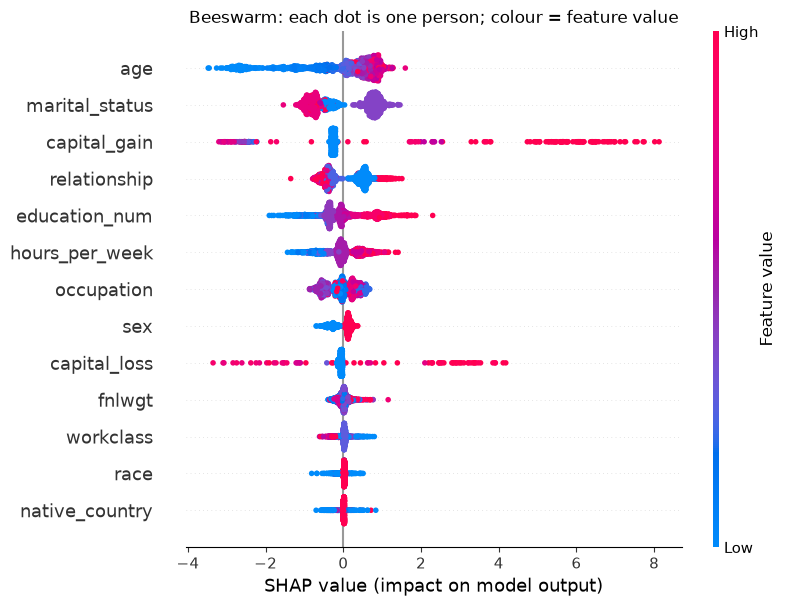

In [24]:
shap.plots.beeswarm(sv, max_display=13, show=False)
plt.title("Beeswarm: each dot is one person; colour = feature value")
plt.show()

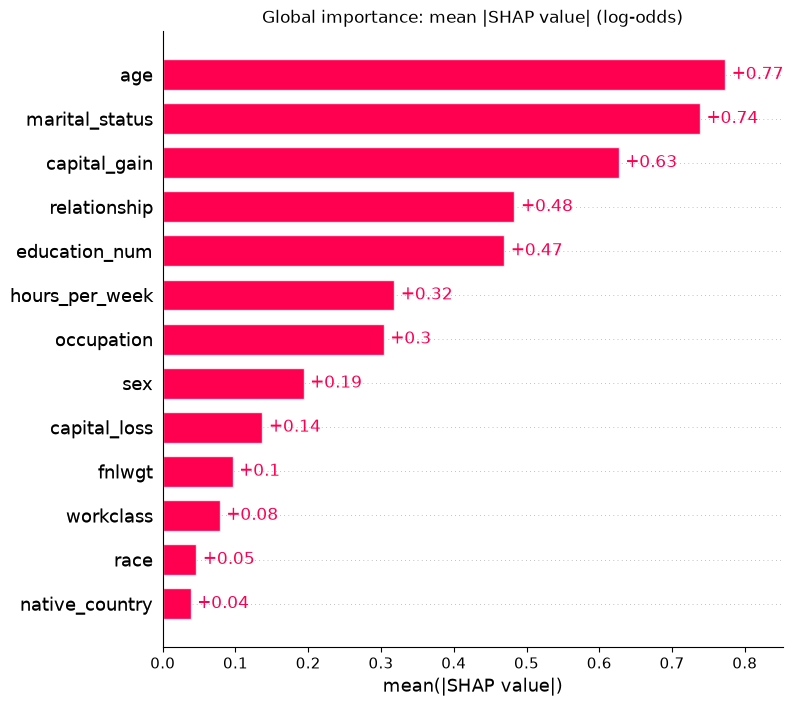

age               0.7729
marital_status    0.7383
capital_gain      0.6266
relationship      0.4834
education_num     0.4693
hours_per_week    0.3182
occupation        0.3037
sex               0.1935
capital_loss      0.1369
fnlwgt            0.0960
workclass         0.0783
race              0.0461
native_country    0.0382


In [25]:
shap.plots.bar(sv, max_display=13, show=False)
plt.title("Global importance: mean |SHAP value| (log-odds)")
plt.show()

global_shap = pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print(global_shap.round(4).to_string())

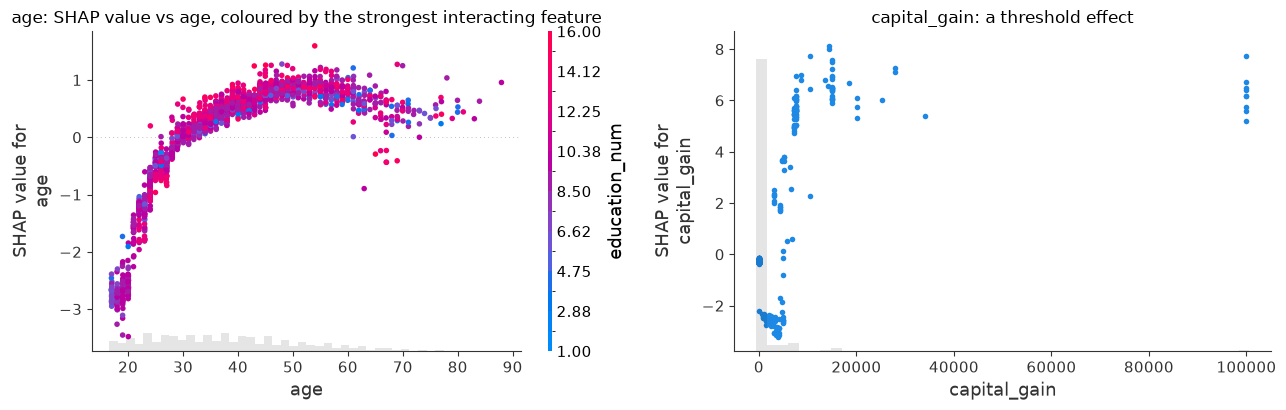

shap picked 'education_num' as the colouring feature for age (its best guess at the strongest interaction)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
shap.plots.scatter(sv[:, "age"], color=sv, ax=axes[0], show=False)
shap.plots.scatter(sv[:, "capital_gain"], ax=axes[1], show=False)
axes[0].set_title("age: SHAP value vs age, coloured by the strongest interacting feature")
axes[1].set_title("capital_gain: a threshold effect")
plt.tight_layout()
plt.show()
partner = FEATURES[shap.utils.approximate_interactions(FEATURES.index("age"), sv.values, X_explain.to_numpy())[0]]   # an int index: name lookup fails with numpy 2.5
print(f"shap picked '{partner}' as the colouring feature for age (its best guess at the strongest interaction)")

**Reading them:** in the beeswarm, red dots (high values) of `capital_gain` sit far right — large capital gains push strongly toward >50K; `relationship` codes separate married from unmarried people. The age scatter rises until middle age, then flattens and falls, with vertical spread explained by the colouring feature. Unlike a PDP, every dot is a **real person**, so no ocean districts.

### ✍️ Your Turn

Which feature has the **largest mean |SHAP|** on `X_explain`? Store its name (a string) in `top_shap_feature`.

In [27]:
top_shap_feature = None  # TODO: your code here
check("top_shap_feature", top_shap_feature, FEATURES[int(np.argmax(np.abs(sv.values).mean(axis=0)))], hint="np.abs(sv.values).mean(axis=0), then argmax → FEATURES[...]")

⏳ top_shap_feature: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
top_shap_feature = pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES).idxmax()
check("top_shap_feature", top_shap_feature, FEATURES[int(np.argmax(np.abs(sv.values).mean(axis=0)))])
```
</details>

> 💡 **Interview angle:** "How do you read a SHAP beeswarm plot?" — features sorted by mean |SHAP|; each dot is one row placed by its SHAP value (left lowers, right raises the output); colour is the feature's value, so red-on-the-right means "higher value → higher prediction". Wide horizontal spread at one colour hints at interactions; check with a scatter/dependence plot.

## 9. Model-Agnostic SHAP: Maskers, Permutation, and LinearExplainer 🔴

For models that aren't trees, `shap` only needs a **prediction function** and a **masker** (the rule that defines "absent" features):

- `shap.maskers.Independent(background, max_samples=...)` — fills absent features from background rows (interventional).
- `shap.explainers.Exact` — all $2^M$ coalitions; fine for ≤ ~12 features.
- `shap.explainers.Permutation` — samples feature orderings (forward and reversed, "antithetic") and walks through each; efficiency still holds exactly; cost ≈ `max_evals` model calls × background rows per row.
- `shap.explainers.Kernel` (KernelSHAP) — a weighted linear regression over sampled coalitions; the classic model-agnostic method, generally slower than Permutation.
- `shap.Explainer(model, masker)` picks an algorithm automatically.

We explain the same LightGBM through its `predict` function only — as if it were a black box — and compare with interventional TreeSHAP using the **same 100 background rows**.

In [28]:
def lgbm_margin(A):
    return lgbm.predict(pd.DataFrame(A, columns=FEATURES), raw_score=True)


perm_explainer = shap.explainers.Permutation(lgbm_margin, shap.maskers.Independent(background_adult, max_samples=100), seed=0)
rows20 = X_explain.iloc[:20]
start = time.perf_counter()
sv_perm = perm_explainer(rows20, silent=True)
t_perm = time.perf_counter() - start
perm_vs_tree = np.abs(sv_perm.values - sv_int.values[:20])
print(f"Permutation explainer: {t_perm:.2f}s for 20 rows ({t_perm / 20 * 1000:.0f} ms/row) vs interventional TreeSHAP {t_int / 500 * 1000:.2f} ms/row "
      f"→ ~{(t_perm / 20) / (t_int / 500):.0f}× slower")
print(f"vs exact interventional TreeSHAP: mean |diff| {perm_vs_tree.mean():.4f}, max |diff| {perm_vs_tree.max():.4f}, "
      f"correlation {np.corrcoef(sv_perm.values.ravel(), sv_int.values[:20].ravel())[0, 1]:.4f}")
print(f"efficiency still exact: max |base + Σφ − margin| = {np.abs(sv_perm.base_values + sv_perm.values.sum(axis=1) - lgbm_margin(rows20.to_numpy())).max():.1e}")

Permutation explainer: 2.09s for 20 rows (104 ms/row) vs interventional TreeSHAP 3.51 ms/row → ~30× slower
vs exact interventional TreeSHAP: mean |diff| 0.0053, max |diff| 0.0489, correlation 0.9999
efficiency still exact: max |base + Σφ − margin| = 1.7e-14


**LinearExplainer.** For a linear model with independent features, the interventional Shapley value has a closed form: $\phi_j = w_j\,(x_j - \mathbb E[x_j])$ — the weight times how far this row is from the background average. We verify on a logistic regression fitted on standardized numeric Adult features (values in log-odds).

In [29]:
scaler_num = StandardScaler().fit(X_tr[NUM_COLS])
Z_tr = pd.DataFrame(scaler_num.transform(X_tr[NUM_COLS]), columns=NUM_COLS, index=X_tr.index)
Z_explain = pd.DataFrame(scaler_num.transform(X_explain[NUM_COLS]), columns=NUM_COLS, index=X_explain.index)
lin_lr = LogisticRegression(max_iter=2000).fit(Z_tr, y_tr)
lin_background = Z_tr.sample(500, random_state=SEED)
lin_explainer = shap.LinearExplainer(lin_lr, shap.maskers.Independent(lin_background, max_samples=500))
sv_lin = lin_explainer(Z_explain.iloc[:100])
closed_form = lin_lr.coef_[0] * (Z_explain.iloc[:100].to_numpy() - lin_background.to_numpy().mean(axis=0))
print(f"LinearExplainer vs w·(x − mean): max |diff| = {np.abs(sv_lin.values - closed_form).max():.2e}")
print(f"base value {sv_lin.base_values[0]:.4f} = intercept + w·mean(background) = {lin_lr.intercept_[0] + lin_lr.coef_[0] @ lin_background.mean().to_numpy():.4f}")
assert np.allclose(sv_lin.values, closed_form, atol=1e-8)

LinearExplainer vs w·(x − mean): max |diff| = 0.00e+00
base value -1.4176 = intercept + w·mean(background) = -1.4176


**Hyperparameter: background size.** Interventional values depend on the background sample. Smaller backgrounds are faster but noisier. We explain 200 rows with 5 different random backgrounds of each size and measure how much the SHAP values move.

In [30]:
bg_rows = []
rows200 = X_explain.iloc[:200]
for bg_size in [10, 50, 200]:
    runs, secs = [], []
    for rep in range(5):
        bg = X_tr.sample(bg_size, random_state=1000 + rep)
        # a plain DataFrame with more than 100 rows would be silently subsampled to 100; a masker keeps every row
        masker_bg = shap.maskers.Independent(bg, max_samples=bg_size)
        start = time.perf_counter()
        runs.append(shap.TreeExplainer(lgbm, data=masker_bg, feature_perturbation="interventional")(rows200).values)
        secs.append(time.perf_counter() - start)
    runs = np.stack(runs)                                    # (5 backgrounds, 200 rows, 13 features)
    global_rankings = [np.abs(r).mean(axis=0) for r in runs]
    bg_rows.append({"background rows": bg_size, "seconds (200 rows)": np.mean(secs),
                    "SD of a SHAP value across backgrounds": runs.std(axis=0).mean(),
                    "mean Spearman ρ of global rankings": np.mean([spearmanr(a, b).statistic for a, b in itertools.combinations(global_rankings, 2)])})
bg_df = pd.DataFrame(bg_rows).round(4)
print(bg_df.to_string(index=False))
sd_small, sd_large = bg_df["SD of a SHAP value across backgrounds"].iloc[0], bg_df["SD of a SHAP value across backgrounds"].iloc[-1]
print(f"→ 20× more background rows: SD {sd_small:.3f} → {sd_large:.3f} ({sd_small / sd_large:.1f}× smaller; pure sampling noise would shrink ≈ √20 = 4.5×) "
      f"while run time grows ≈ linearly. 100–500 rows is the usual sweet spot.")

 background rows  seconds (200 rows)  SD of a SHAP value across backgrounds  mean Spearman ρ of global rankings
              10              0.1707                                 0.1059                              0.9275
              50              0.4886                                 0.0551                              0.9637
             200              1.5446                                 0.0322                              0.9945
→ 20× more background rows: SD 0.106 → 0.032 (3.3× smaller; pure sampling noise would shrink ≈ √20 = 4.5×) while run time grows ≈ linearly. 100–500 rows is the usual sweet spot.


### ✍️ Your Turn

Using the closed form (not the explainer), compute the LinearExplainer SHAP value of `age` for the **first** row of `Z_explain`, with `lin_lr` and `lin_background`. Store it in `lin_age_row0`.

In [31]:
lin_age_row0 = None  # TODO: your code here
check("lin_age_row0", lin_age_row0, sv_lin.values[0, NUM_COLS.index("age")], hint="w_age * (z_age_row0 − background mean of z_age)")

⏳ lin_age_row0: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
j = NUM_COLS.index("age")
lin_age_row0 = lin_lr.coef_[0][j] * (Z_explain.iloc[0, j] - lin_background.iloc[:, j].mean())
check("lin_age_row0", lin_age_row0, sv_lin.values[0, NUM_COLS.index("age")])
```
</details>

> 💡 **Interview angle:** "How do you compute SHAP for a neural net or an SVM?" — use a model-agnostic explainer (Permutation or KernelSHAP; DeepSHAP/GradientSHAP for neural nets) with a background masker of ~100–500 rows; it's orders of magnitude slower than TreeSHAP, so explain a sample of rows, cache results, and batch predictions. For linear models there's a closed form $\phi_j = w_j(x_j - \mathbb E[x_j])$.

## 10. LIME: Local Surrogates and Their Instability 🔴

**LIME** (Ribeiro et al. 2016) explains one prediction by fitting a simple model **around** it:

1. **Perturb:** generate `num_samples` fake rows near $x$ (tabular LIME samples each feature from training statistics, and by default turns continuous features into quartile bins).
2. **Predict** those rows with the black-box model.
3. **Weight** each fake row by closeness to $x$ with an exponential kernel $\pi_x(z) = \sqrt{\exp(-d(x,z)^2/\sigma^2)}$, where $\sigma$ = `kernel_width` (default $0.75\sqrt{d}$).
4. **Fit** a weighted ridge regression on (a selection of) features; its coefficients are the explanation.

```
  model output                 LIME fits a line that is accurate only near x
       |         ___/‾‾‾\___        (the kernel width decides what "near" means)
       |   ___/‾‾   x•      ‾‾\
       |__/          \‾‾ local line
       +-------------------------------- feature
```

The explanation depends on random sampling and on the kernel width, so let's measure how much.

In [32]:
lime_train = X_tr.sample(5000, random_state=SEED).to_numpy()
cat_idx = [FEATURES.index(c) for c in CAT_COLS]
cat_names = {FEATURES.index(c): CATEGORIES[c] for c in CAT_COLS}


def predict_proba_frame(A):
    return lgbm.predict_proba(pd.DataFrame(A, columns=FEATURES))


def make_lime(seed, kernel_width=None):
    return lime.lime_tabular.LimeTabularExplainer(lime_train, mode="classification", feature_names=FEATURES,
                                                  categorical_features=cat_idx, categorical_names=cat_names,
                                                  class_names=["<=50K", ">50K"], kernel_width=kernel_width,
                                                  discretize_continuous=True, random_state=seed)


lime_row_pos = 7
lime_row = X_explain.iloc[lime_row_pos].to_numpy()
exp0 = make_lime(0).explain_instance(lime_row, predict_proba_frame, num_features=6, num_samples=2000)
print(f"model P(>50K) = {predict_proba_frame(lime_row[None, :])[0, 1]:.3f} | LIME surrogate's prediction at x = {exp0.local_pred[0]:.3f} | "
      f"surrogate weighted R² = {exp0.score:.3f} | default kernel width = {0.75 * np.sqrt(len(FEATURES)):.2f}")
for rule, weight in exp0.as_list():
    print(f"  {weight:+.4f}  {rule}")

model P(>50K) = 0.051 | LIME surrogate's prediction at x = 0.040 | surrogate weighted R² = 0.680 | default kernel width = 2.70
  -0.6977  capital_gain <= 0.00
  -0.1159  age <= 28.00
  +0.0833  marital_status=Married-civ-spouse
  -0.0815  hours_per_week <= 40.00
  -0.0723  education_num <= 9.00
  +0.0512  relationship=Husband


**Instability experiment.** Same row, same model, 10 random seeds, at three sample sizes. We compare the **top-5 feature sets** (mean pairwise Jaccard overlap: 1 = identical), how often the top-1 feature agrees, and the Spearman correlation of the full weight vectors. As a reference, SHAP's Permutation explainer (also random) with 10 seeds, and TreeSHAP (deterministic).

In [33]:
def mean_pairwise_jaccard(sets):
    return float(np.mean([len(a & b) / len(a | b) for a, b in itertools.combinations(sets, 2)]))


def mean_pairwise_spearman(vectors):
    return float(np.mean([spearmanr(a, b).statistic for a, b in itertools.combinations(vectors, 2)]))


def lime_vector(explanation):
    vec = np.zeros(len(FEATURES))
    for f, w in explanation.as_map()[1]:
        vec[f] = w
    return vec


def stability_row(label, vectors, seconds):
    top5 = [set(np.argsort(-np.abs(v_))[:5]) for v_ in vectors]
    top1 = [int(np.argmax(np.abs(v_))) for v_ in vectors]
    return {"method": label, "top-5 Jaccard": mean_pairwise_jaccard(top5),
            "top-1 agreement": max(top1.count(t) for t in set(top1)) / len(top1),
            "Spearman of weights": mean_pairwise_spearman(vectors), "s per explanation": seconds / len(vectors)}


stab_rows = []
for n_samples in [500, 2000, 5000]:
    start = time.perf_counter()
    vecs = [lime_vector(make_lime(s).explain_instance(lime_row, predict_proba_frame, num_features=len(FEATURES), num_samples=n_samples))
            for s in range(10)]
    stab_rows.append(stability_row(f"LIME, num_samples={n_samples}", vecs, time.perf_counter() - start))

start = time.perf_counter()
masker_100 = shap.maskers.Independent(background_adult, max_samples=100)
vecs = [shap.explainers.Permutation(lgbm_margin, masker_100, seed=s)(X_explain.iloc[[lime_row_pos]], silent=True).values[0] for s in range(10)]
stab_rows.append(stability_row("SHAP Permutation (500 evals)", vecs, time.perf_counter() - start))
start = time.perf_counter()
vecs = [shap.TreeExplainer(lgbm)(X_explain.iloc[[lime_row_pos]]).values[0] for _ in range(10)]
stab_rows.append(stability_row("TreeSHAP (deterministic)", vecs, time.perf_counter() - start))
stability = pd.DataFrame(stab_rows).round(3)
print(stability.to_string(index=False))
lime_small = stability.iloc[0]
print(f"\n→ with 500 samples, two LIME runs share on average {lime_small['top-5 Jaccard']:.0%} of their top-5 features "
      f"(Jaccard); SHAP Permutation: {stability.iloc[3]['top-5 Jaccard']:.0%}")

                      method  top-5 Jaccard  top-1 agreement  Spearman of weights  s per explanation
       LIME, num_samples=500          0.763              1.0                0.892              0.009
      LIME, num_samples=2000          0.770              1.0                0.947              0.014
      LIME, num_samples=5000          0.881              1.0                0.987              0.026
SHAP Permutation (500 evals)          1.000              1.0                0.987              0.065
    TreeSHAP (deterministic)          1.000              1.0                1.000              0.078

→ with 500 samples, two LIME runs share on average 76% of their top-5 features (Jaccard); SHAP Permutation: 100%


**Hyperparameter: kernel width.** A narrow kernel trusts only very close samples (noisy); a wide one fits a near-global line (not local). There's no principled way to choose it — which is the main criticism of LIME.

In [34]:
width_rows = []
for width in [0.5, 1.0, 0.75 * np.sqrt(len(FEATURES)), 5.0, 25.0]:
    e = make_lime(0, kernel_width=width).explain_instance(lime_row, predict_proba_frame, num_features=len(FEATURES), num_samples=5000)
    top3 = [FEATURES[i] for i in np.argsort(-np.abs(lime_vector(e)))[:3]]
    width_rows.append({"kernel_width": round(width, 2), "top-3 features": ", ".join(top3), "surrogate R²": round(e.score, 3),
                       "surrogate P at x": round(float(e.local_pred[0]), 3)})
print(pd.DataFrame(width_rows).to_string(index=False))
print(f"model's real P at x: {predict_proba_frame(lime_row[None, :])[0, 1]:.3f}")

 kernel_width                   top-3 features  surrogate R²  surrogate P at x
          0.5 age, education_num, capital_gain         0.222             0.038
          1.0 capital_gain, age, education_num         0.615             0.030
          2.7 capital_gain, age, education_num         0.630             0.041
          5.0 capital_gain, age, education_num         0.631             0.043
         25.0 capital_gain, age, education_num         0.632             0.043
model's real P at x: 0.051


### ✍️ Your Turn

From `exp0` (the first LIME explanation), which **feature index** has the largest absolute weight? Store the feature **name** in `lime_top_feature`.

In [35]:
lime_top_feature = None  # TODO: your code here
check("lime_top_feature", lime_top_feature, FEATURES[max(exp0.as_map()[1], key=lambda fw: abs(fw[1]))[0]],
      hint="exp0.as_map()[1] is a list of (feature_index, weight); take the max by abs(weight), then FEATURES[index].")

⏳ lime_top_feature: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
best_index, best_weight = max(exp0.as_map()[1], key=lambda fw: abs(fw[1]))
lime_top_feature = FEATURES[best_index]
check("lime_top_feature", lime_top_feature, FEATURES[max(exp0.as_map()[1], key=lambda fw: abs(fw[1]))[0]])
```
Rerun `make_lime(1)` for the same row and see whether the answer changes.
</details>

> 💡 **Interview angle:** "SHAP or LIME?" — both are local and model-agnostic, but SHAP's attributions come with guarantees (they add up to the prediction; symmetric; zero for unused features) and TreeSHAP is exact, fast and deterministic, so it's the default for tabular models. LIME is a weighted local linear fit whose result depends on sampling and an arbitrary kernel width — we measured top-5 overlap well below 100% between seeds. LIME is still handy for quick checks on text and images.

## 11. Counterfactual Explanations 🟡

A **counterfactual explanation** answers the question a denied applicant actually asks: *"What is the smallest change that would have flipped the decision?"* (Wachter et al. 2017). A good counterfactual is:

- **valid** — the model's decision really flips;
- **minimal** — the change is small (measured in standardized units, so years and hours are comparable);
- **actionable and plausible** — only features the person can change (not age, race, or sex), in allowed directions (education can't go down), within realistic ranges.

Libraries like DiCE and Alibi search with optimization and diversity constraints. Here we hand-roll the simplest version: a grid search over two actionable features for a person the model scores just below 50%.

applicant (test row 0): age 38, education_num 9 (HS-grad), hours/week 40, occupation Craft-repair
model: P(>50K) = 0.316 → below 0.5
smallest flip: education_num 9 → 13, hours/week 40 → 40 | P = 0.510 | cost 1.55 SD | 35 of 72 grid points flip


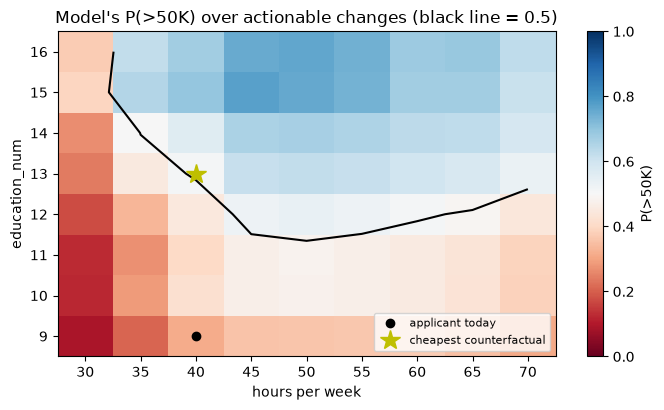

In [36]:
sd_tr = X_tr[NUM_COLS].std()
candidates_pos = np.flatnonzero((proba_te > 0.30) & (proba_te < 0.45) & (X_te["education_num"].to_numpy() <= 12))
cf_result = None
for pos in candidates_pos[:50]:
    applicant = X_te.iloc[pos]
    edu_values = np.arange(applicant["education_num"], 17)                                    # education can only go up
    hour_values = np.unique(np.clip(np.arange(applicant["hours_per_week"] - 10, applicant["hours_per_week"] + 31, 5), 1, 99))
    grid = pd.DataFrame([applicant.to_dict() | {"education_num": e, "hours_per_week": h} for e in edu_values for h in hour_values])[FEATURES]
    grid_proba = lgbm.predict_proba(grid)[:, 1]
    cost = (np.abs(grid["education_num"] - applicant["education_num"]) / sd_tr["education_num"]
            + np.abs(grid["hours_per_week"] - applicant["hours_per_week"]) / sd_tr["hours_per_week"]).to_numpy()
    flips = grid_proba >= 0.5
    if flips.any():
        cf_result = dict(pos=pos, applicant=applicant, grid=grid, grid_proba=grid_proba, cost=cost, flips=flips,
                         edu_values=edu_values, hour_values=hour_values)
        break

assert cf_result is not None, "no candidate in the first 50 could be flipped with these two features"
best = int(np.argmin(np.where(cf_result["flips"], cf_result["cost"], np.inf)))
app, g_best = cf_result["applicant"], cf_result["grid"].iloc[best]
print(f"applicant (test row {cf_result['pos']}): age {app['age']:.0f}, education_num {app['education_num']:.0f} "
      f"({raw_te.iloc[cf_result['pos']]['education']}), hours/week {app['hours_per_week']:.0f}, occupation {raw_te.iloc[cf_result['pos']]['occupation']}")
print(f"model: P(>50K) = {proba_te[cf_result['pos']]:.3f} → below 0.5")
print(f"smallest flip: education_num {app['education_num']:.0f} → {g_best['education_num']:.0f}, hours/week {app['hours_per_week']:.0f} → {g_best['hours_per_week']:.0f} "
      f"| P = {cf_result['grid_proba'][best]:.3f} | cost {cf_result['cost'][best]:.2f} SD | {cf_result['flips'].sum()} of {len(cf_result['grid'])} grid points flip")

heat = cf_result["grid_proba"].reshape(len(cf_result["edu_values"]), len(cf_result["hour_values"]))
fig, ax = plt.subplots(figsize=(7, 4.2))
im = ax.imshow(heat, origin="lower", aspect="auto", cmap="RdBu", vmin=0, vmax=1,
               extent=[cf_result["hour_values"][0] - 2.5, cf_result["hour_values"][-1] + 2.5, cf_result["edu_values"][0] - 0.5, cf_result["edu_values"][-1] + 0.5])
ax.contour(cf_result["hour_values"], cf_result["edu_values"], heat, levels=[0.5], colors="k")
ax.plot(app["hours_per_week"], app["education_num"], "ko", label="applicant today")
ax.plot(g_best["hours_per_week"], g_best["education_num"], "y*", ms=15, label="cheapest counterfactual")
ax.set(xlabel="hours per week", ylabel="education_num", title="Model's P(>50K) over actionable changes (black line = 0.5)")
fig.colorbar(im, ax=ax, label="P(>50K)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

A counterfactual explains **the model's decision boundary**, not reality: it says "this model would have said yes", not "more education will raise your income". It also depends on the model version — retrain and the advice may change.

### ✍️ Your Turn

How many grid points in `cf_result` would flip the decision **while raising hours per week by at most 10**? Store the integer in `n_flips_10h`.

In [37]:
n_flips_10h = None  # TODO: your code here
check("n_flips_10h", n_flips_10h,
      int((cf_result["flips"] & ((cf_result["grid"]["hours_per_week"] - cf_result["applicant"]["hours_per_week"]).to_numpy() <= 10)).sum()),
      hint="Combine cf_result['flips'] with a boolean mask on grid['hours_per_week'] − applicant['hours_per_week'] <= 10.")

⏳ n_flips_10h: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
extra_hours = (cf_result["grid"]["hours_per_week"] - cf_result["applicant"]["hours_per_week"]).to_numpy()
n_flips_10h = int((cf_result["flips"] & (extra_hours <= 10)).sum())
check("n_flips_10h", n_flips_10h,
      int((cf_result["flips"] & ((cf_result["grid"]["hours_per_week"] - cf_result["applicant"]["hours_per_week"]).to_numpy() <= 10)).sum()))
```
</details>

> 💡 **Interview angle:** "How would you tell a rejected applicant what to change?" — generate counterfactuals: the minimal, valid change on actionable features (with immutable features frozen and monotonic constraints like "education can't decrease"), measured in scaled units, ideally several diverse options. Pair them with SHAP-based reason codes, and caveat that they describe the current model, not causal guarantees.

## 12. Explaining the Model, Not the World: Proxies and Causality 🔴

SHAP tells you **what the model uses**. It does **not** tell you what *causes* the outcome, and removing a sensitive column does not remove its information. Two experiments on Adult:

1. **Proxies.** How well do `relationship` and `marital_status` predict `sex`? If we drop them, does the model lean harder on `sex`? If we drop `sex`, do predictions for men and women stop differing?
2. **Confounding.** `relationship = Husband` gets a big SHAP value. Husbands also differ in age, hours, and occupation — so "becoming a husband raises income" would be a causal leap the data can't support.

In [38]:
is_male_tr = (raw_tr["sex"] == "Male").astype(int).to_numpy()
proxy_model = make_pipeline(OneHotEncoder(handle_unknown="ignore"), LogisticRegression(max_iter=2000))
proxy_auc = cross_val_score(proxy_model, raw_tr[["relationship", "marital_status"]], is_male_tr, cv=5, scoring="roc_auc").mean()
print(f"relationship + marital_status predict sex with CV ROC-AUC {proxy_auc:.3f} → strong proxies")

no_family = [f for f in FEATURES if f not in ("relationship", "marital_status")]
no_sex = [f for f in FEATURES if f != "sex"]
lgbm_no_family = lgb.LGBMClassifier(**LGBM_PARAMS).fit(X_tr[no_family], y_tr)
lgbm_no_sex = lgb.LGBMClassifier(**LGBM_PARAMS).fit(X_tr[no_sex], y_tr)

rows1000 = X_te.iloc[:1000]


def shap_share(model, cols, feature):
    values = np.abs(shap.TreeExplainer(model)(rows1000[cols]).values).mean(axis=0)
    return values[cols.index(feature)] / values.sum()


male_te = (raw_te["sex"] == "Male").to_numpy()
proxy_rows = []
for name, model, cols in [("all features", lgbm, FEATURES), ("without relationship & marital_status", lgbm_no_family, no_family),
                          ("without sex", lgbm_no_sex, no_sex)]:
    p = model.predict_proba(X_te[cols])[:, 1]
    proxy_rows.append({"model": name, "test AUC": roc_auc_score(y_te, p),
                       "sex's share of mean|SHAP|": shap_share(model, cols, "sex") if "sex" in cols else np.nan,
                       "flag rate men": np.mean(p[male_te] > 0.5), "flag rate women": np.mean(p[~male_te] > 0.5)})
proxy_df = pd.DataFrame(proxy_rows)
proxy_df["gap (men − women)"] = proxy_df["flag rate men"] - proxy_df["flag rate women"]
print(proxy_df.round(3).to_string(index=False))
share_full, share_nofam = proxy_df.loc[0, "sex's share of mean|SHAP|"], proxy_df.loc[1, "sex's share of mean|SHAP|"]
print(f"\n→ dropping the family columns multiplies sex's SHAP share by {share_nofam / share_full:.1f}× (the model routes the same signal through sex)")
print(f"→ dropping sex changes the men/women flag-rate gap from {proxy_df.loc[0, 'gap (men − women)']:.3f} to {proxy_df.loc[2, 'gap (men − women)']:.3f} "
      f"— 'fairness through unawareness' barely moves it")

relationship + marital_status predict sex with CV ROC-AUC 0.875 → strong proxies


                                model  test AUC  sex's share of mean|SHAP|  flag rate men  flag rate women  gap (men − women)
                         all features     0.931                      0.045          0.254            0.082              0.172
without relationship & marital_status     0.902                      0.104          0.228            0.043              0.185
                          without sex     0.930                        NaN          0.253            0.084              0.169

→ dropping the family columns multiplies sex's SHAP share by 2.3× (the model routes the same signal through sex)
→ dropping sex changes the men/women flag-rate gap from 0.172 to 0.169 — 'fairness through unawareness' barely moves it


In [39]:
husband = (raw_tr["relationship"] == "Husband").to_numpy()
confound = pd.DataFrame({
    "husbands": [raw_tr.loc[husband, "age"].mean(), raw_tr.loc[husband, "hours_per_week"].mean(), raw_tr.loc[husband, "education_num"].mean(), y_tr[husband].mean()],
    "everyone else": [raw_tr.loc[~husband, "age"].mean(), raw_tr.loc[~husband, "hours_per_week"].mean(), raw_tr.loc[~husband, "education_num"].mean(), y_tr[~husband].mean()],
}, index=["mean age", "mean hours/week", "mean education_num", "share >50K"])
print(confound.round(2).to_string())
rel_codes = X_explain["relationship"].to_numpy()
husband_code = CATEGORIES["relationship"].index("Husband")
print(f"\nmean SHAP of relationship: husbands {sv.values[rel_codes == husband_code, FEATURES.index('relationship')].mean():+.3f} "
      f"vs others {sv.values[rel_codes != husband_code, FEATURES.index('relationship')].mean():+.3f} log-odds")
print("The model found a strong *association*; husbands are also older and work longer hours, and the census can't separate cause from correlation.")

                    husbands  everyone else
mean age               43.99          35.14
mean hours/week        44.27          37.88
mean education_num     10.33           9.91
share >50K              0.45           0.10

mean SHAP of relationship: husbands +0.511 vs others -0.320 log-odds
The model found a strong *association*; husbands are also older and work longer hours, and the census can't separate cause from correlation.


**What to do instead:** use explanations to *generate hypotheses* and to *audit* models; answer causal questions with experiments (A/B tests) or causal-inference methods (e.g. DoWhy, EconML) that model confounders explicitly. For fairness, measure outcomes by group (flag rates, error rates) rather than trusting that a removed column is gone.

**Text and image models (pointer).** The same ideas extend: SHAP's `Partition` explainer and LIME can mask words or superpixels, and gradient-based methods such as Integrated Gradients and **Grad-CAM** highlight the pixels a CNN used — see [06 · CNNs and Transfer Learning, section 11](../06_Computer_Vision/02_CNNs_and_Transfer_Learning.ipynb), which builds Grad-CAM heatmaps on a real image model.

### ✍️ Your Turn

For the **"without sex"** model, what share of all test **women** does it flag (P > 0.5)? Store it in `women_flag_rate_no_sex`.

In [40]:
women_flag_rate_no_sex = None  # TODO: your code here
check("women_flag_rate_no_sex", women_flag_rate_no_sex, np.mean(lgbm_no_sex.predict_proba(X_te[no_sex])[:, 1][~male_te] > 0.5),
      hint="Predict with lgbm_no_sex on X_te[no_sex], select rows where male_te is False, compare with 0.5, take the mean.")

⏳ women_flag_rate_no_sex: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_no_sex = lgbm_no_sex.predict_proba(X_te[no_sex])[:, 1]
women_flag_rate_no_sex = np.mean(p_no_sex[~male_te] > 0.5)
check("women_flag_rate_no_sex", women_flag_rate_no_sex, np.mean(lgbm_no_sex.predict_proba(X_te[no_sex])[:, 1][~male_te] > 0.5))
```
</details>

> 💡 **Interview angle:** "Does a large SHAP value mean the feature causes the outcome?" — no. SHAP attributes the *model's* output; correlated or confounded features get credit for associations, and interventional SHAP even evaluates unrealistic feature combinations. Dropping a protected attribute doesn't remove it when proxies exist (here relationship and marital status predict sex with a cross-validated AUC near 0.88) — audit outcomes per group instead.

## 13. Head-to-Head: Do the Explainers Agree? 🟡

Same model (`lgbm`), same 2,000 held-out rows. We compute a **global** ranking with each method — LightGBM split count and gain, permutation importance (test AUC drop), mean |TreeSHAP|, and mean |LIME weight| over 25 rows — then compare rankings with Spearman correlation and record run time.

                                  #1              #2              #3  seconds
LightGBM split count             age          fnlwgt    capital_gain    0.000
LightGBM gain           relationship    capital_gain   education_num    0.000
permutation (test AUC)  capital_gain             age   education_num    0.436
mean |TreeSHAP|                  age  marital_status    capital_gain    0.080
mean |LIME| (25 rows)   capital_gain  hours_per_week  marital_status    0.137


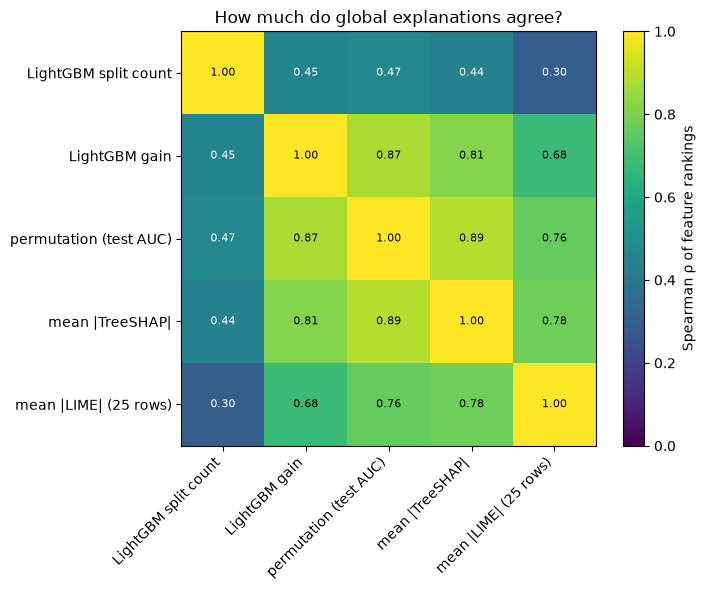

most similar rankings: permutation (test AUC) vs mean |TreeSHAP| (ρ = 0.89)
least similar rankings: LightGBM split count vs mean |LIME| (25 rows) (ρ = 0.30)
average ρ among gain / permutation / TreeSHAP: 0.86 | split count vs those three: 0.45 | LIME vs those three: 0.74
→ split count agrees least with the effect-based methods


In [41]:
h2h, h2h_time = {}, {}
start = time.perf_counter()
h2h["LightGBM split count"] = lgbm.booster_.feature_importance("split").astype(float)
h2h_time["LightGBM split count"] = time.perf_counter() - start
start = time.perf_counter()
h2h["LightGBM gain"] = lgbm.booster_.feature_importance("gain")
h2h_time["LightGBM gain"] = time.perf_counter() - start
start = time.perf_counter()
h2h["permutation (test AUC)"] = permutation_importance(lgbm, X_explain, y_explain, scoring="roc_auc", n_repeats=5, random_state=SEED).importances_mean
h2h_time["permutation (test AUC)"] = time.perf_counter() - start
h2h["mean |TreeSHAP|"] = np.abs(sv.values).mean(axis=0)
h2h_time["mean |TreeSHAP|"] = t_path
start = time.perf_counter()
lime_explainer = make_lime(0)
h2h["mean |LIME| (25 rows)"] = np.mean([np.abs(lime_vector(lime_explainer.explain_instance(X_explain.iloc[i].to_numpy(), predict_proba_frame,
                                                                                        num_features=len(FEATURES), num_samples=1000)))
                                         for i in range(25)], axis=0)
h2h_time["mean |LIME| (25 rows)"] = time.perf_counter() - start
h2h_df = pd.DataFrame(h2h, index=FEATURES)
rho = h2h_df.corr(method="spearman")
top3 = pd.DataFrame({m: h2h_df[m].sort_values(ascending=False).index[:3].tolist() for m in h2h_df.columns}, index=["#1", "#2", "#3"]).T
top3["seconds"] = pd.Series(h2h_time).round(3)
print(top3.to_string())

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(rho.to_numpy(), cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(rho)), rho.columns, rotation=45, ha="right")
ax.set_yticks(range(len(rho)), rho.index)
for i in range(len(rho)):
    for j in range(len(rho)):
        ax.text(j, i, f"{rho.iloc[i, j]:.2f}", ha="center", va="center", color="w" if rho.iloc[i, j] < 0.6 else "k", fontsize=8)
fig.colorbar(im, ax=ax, label="Spearman ρ of feature rankings")
ax.set_title("How much do global explanations agree?")
plt.tight_layout()
plt.show()

pairs = rho.where(np.triu(np.ones(rho.shape, dtype=bool), k=1)).stack()
print(f"most similar rankings: {pairs.idxmax()[0]} vs {pairs.idxmax()[1]} (ρ = {pairs.max():.2f})")
print(f"least similar rankings: {pairs.idxmin()[0]} vs {pairs.idxmin()[1]} (ρ = {pairs.min():.2f})")
effect_methods = ["LightGBM gain", "permutation (test AUC)", "mean |TreeSHAP|"]
within_effect = np.mean([rho.loc[a, b] for a, b in itertools.combinations(effect_methods, 2)])
split_vs_effect = rho.loc["LightGBM split count", effect_methods].mean()
lime_vs_effect = rho.loc["mean |LIME| (25 rows)", effect_methods].mean()
print(f"average ρ among gain / permutation / TreeSHAP: {within_effect:.2f} | split count vs those three: {split_vs_effect:.2f} | "
      f"LIME vs those three: {lime_vs_effect:.2f}")
print(f"→ {'split count agrees least with the effect-based methods' if split_vs_effect < min(within_effect, lime_vs_effect) else 'split count is not the least-agreeing method in this run'}")

**How to read it:** gain, permutation importance, and TreeSHAP all measure an *effect* — on the training loss, the held-out score, or the predictions — so compare the printed average agreement among them with split count (which rewards features offering many split points, like `fnlwgt`) and with LIME's global average (noisy, and shaped by its quartile discretization). When methods disagree, trust the ones computed on held-out data with a clear definition, and check correlated features before concluding anything.

> 💡 **Interview angle:** "Your SHAP ranking and your permutation-importance ranking disagree — which is right?" — they answer different questions: mean |SHAP| measures how much a feature moves predictions (even if those moves don't improve accuracy), permutation importance measures how much the *score* drops when the feature's information is destroyed. A feature can move predictions a lot yet be redundant (a correlated twin compensates), or be used for noise-fitting. Check correlations and compute both on held-out data.

## 🔧 Build It From Scratch

Two core ideas, rebuilt with NumPy and checked against the libraries:

**(a) Exact interventional Shapley values** for a model with all 8 California features. We enumerate all $2^8 = 256$ coalitions, evaluate the value function $v(S) = \frac{1}{|B|}\sum_{b\in B} f(x_S, b_{\bar S})$ in **one batched prediction** (256 coalitions × 50 background rows), then apply the Shapley weights. We assert (1) efficiency, (2) equality with `shap.explainers.Exact` using the same background, and (3) equality with interventional TreeSHAP — three independent routes to the same numbers.

**(b) Permutation importance**, reproducing scikit-learn's exact random-number scheme (read from `sklearn/inspection/_permutation_importance.py`): one integer seed is drawn from `random_state` and **reused for every column**; each column gets a fresh `RandomState(seed)`; the same index array is shuffled again on every repeat, and the column is permuted cumulatively.

In [42]:
def exact_shapley_values(predict, x, background):
    """Interventional Shapley values of one row x by enumerating all 2^M coalitions (background-average value function)."""
    x = np.asarray(x, dtype=float)
    B = np.asarray(background, dtype=float)
    M = len(x)
    masks = np.array(list(itertools.product([False, True], repeat=M)))          # (2^M, M); masks[0] = empty coalition
    stacked = np.where(masks[:, None, :], x[None, None, :], B[None, :, :])       # (2^M, |B|, M): x's values where "present"
    values = predict(stacked.reshape(-1, M)).reshape(len(masks), len(B)).mean(axis=1)   # v(S) for every coalition
    powers = 2 ** np.arange(M - 1, -1, -1)                                       # mask → row index in `masks`
    sizes = masks.sum(axis=1)
    weights = np.array([math.factorial(s) * math.factorial(M - s - 1) / math.factorial(M) for s in range(M)])
    phi = np.zeros(M)
    for k, mask in enumerate(masks):
        for j in np.flatnonzero(~mask):                                          # add feature j to coalition S = mask
            phi[j] += weights[sizes[k]] * (values[k + powers[j]] - values[k])
    return phi, values[0]


lgbm_ca = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=0, n_jobs=N_JOBS, verbose=-1).fit(X_ca_tr, y_ca_tr)
ca_columns = list(X_ca.columns)


def predict_ca(A):
    return lgbm_ca.predict(pd.DataFrame(A, columns=ca_columns))


background_bs = X_ca_tr.sample(50, random_state=SEED)
rows_bs = X_ca_te.iloc[:5]

start = time.perf_counter()
ours = [exact_shapley_values(predict_ca, rows_bs.iloc[i], background_bs) for i in range(len(rows_bs))]
t_ours = time.perf_counter() - start
phi_ours = np.array([p for p, _ in ours])
base_ours = ours[0][1]

efficiency_gap = np.abs(phi_ours.sum(axis=1) - (predict_ca(rows_bs.to_numpy()) - base_ours)).max()
assert efficiency_gap < 1e-9, efficiency_gap

start = time.perf_counter()
sv_exact = shap.explainers.Exact(predict_ca, shap.maskers.Independent(background_bs, max_samples=len(background_bs)))(rows_bs, silent=True)
t_exact = time.perf_counter() - start
assert np.allclose(phi_ours, sv_exact.values, atol=1e-8) and np.isclose(base_ours, sv_exact.base_values[0])

start = time.perf_counter()
sv_tree_bs = shap.TreeExplainer(lgbm_ca, data=background_bs, feature_perturbation="interventional")(rows_bs)
t_tree_bs = time.perf_counter() - start
assert np.allclose(phi_ours, sv_tree_bs.values, atol=1e-5)

print(pd.DataFrame(phi_ours, columns=ca_columns, index=[f"district {i}" for i in range(len(rows_bs))]).round(4).to_string())
print(f"\n✅ efficiency: max |Σφ − (f(x) − E[f])| = {efficiency_gap:.1e}")
print(f"✅ matches shap.explainers.Exact: max |diff| = {np.abs(phi_ours - sv_exact.values).max():.1e}")
print(f"✅ matches interventional TreeSHAP: max |diff| = {np.abs(phi_ours - sv_tree_bs.values).max():.1e}")
print(f"time for 5 rows — ours {t_ours:.2f}s ({2 ** len(ca_columns)} coalitions × {len(background_bs)} background rows per row) | "
      f"shap Exact {t_exact:.2f}s | TreeSHAP {t_tree_bs:.3f}s")

            MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
district 0 -0.4575   -0.0087   -0.0368    -0.0077     -0.0110   -0.2311   -0.4589    -0.2780
district 1 -0.3444    0.0180   -0.0583     0.0455      0.0060   -0.0291   -0.3968    -0.2724
district 2  0.1345    0.3293   -0.0267     0.0478     -0.0002    0.6847    0.0890     1.5318
district 3  0.5721   -0.0557    0.1101    -0.0279      0.0043   -0.4005    0.2736    -0.1191
district 4 -0.0465    0.0122    0.0179    -0.0082     -0.0103    0.0409   -0.2723     0.5694

✅ efficiency: max |Σφ − (f(x) − E[f])| = 6.1e-16
✅ matches shap.explainers.Exact: max |diff| = 2.5e-15
✅ matches interventional TreeSHAP: max |diff| = 8.7e-08
time for 5 rows — ours 0.15s (256 coalitions × 50 background rows per row) | shap Exact 0.15s | TreeSHAP 0.089s


In [43]:
def permutation_importance_scratch(model, X, y, scoring, n_repeats, random_state):
    """Mirror of sklearn.inspection.permutation_importance (single process): returns importances of shape (n_features, n_repeats)."""
    scorer = get_scorer(scoring)
    seed = check_random_state(random_state).randint(np.iinfo(np.int32).max + 1)   # ONE seed, shared by every column
    baseline = scorer(model, X, y)
    importances = np.zeros((X.shape[1], n_repeats))
    for j, col in enumerate(X.columns):
        gen = np.random.RandomState(seed)                                          # fresh generator per column, same seed
        order = np.arange(len(X))
        X_perm = X.copy()
        for r in range(n_repeats):
            gen.shuffle(order)                                                     # the same index array is reshuffled each repeat
            X_perm[col] = X_perm[col].to_numpy()[order]                            # cumulative permutation of this column
            importances[j, r] = baseline - scorer(model, X_perm, y)
    return importances


for label, model, X_check, y_check, scoring in [("LightGBM on Adult, ROC-AUC", lgbm, X_explain.iloc[:1500], y_explain[:1500], "roc_auc"),
                                                ("HistGradientBoosting on California, R²", hgb_ca, X_ca_te.iloc[:1500], y_ca_te.iloc[:1500], "r2")]:
    start = time.perf_counter()
    mine = permutation_importance_scratch(model, X_check, y_check, scoring, n_repeats=3, random_state=7)
    t_mine = time.perf_counter() - start
    theirs = permutation_importance(model, X_check, y_check, scoring=scoring, n_repeats=3, random_state=7)
    assert np.allclose(mine, theirs.importances, rtol=0, atol=1e-12)
    top_feature = X_check.columns[int(np.argmax(mine.mean(axis=1)))]
    print(f"✅ {label}: all {mine.size} importances identical to scikit-learn (max |diff| {np.abs(mine - theirs.importances).max():.1e}); "
          f"top feature '{top_feature}'; ours took {t_mine:.2f}s")

✅ LightGBM on Adult, ROC-AUC: all 39 importances identical to scikit-learn (max |diff| 0.0e+00); top feature 'capital_gain'; ours took 0.21s


✅ HistGradientBoosting on California, R²: all 24 importances identical to scikit-learn (max |diff| 0.0e+00); top feature 'Latitude'; ours took 1.32s


**What the build teaches:** Shapley values are nothing more than a weighted average of "prediction with the feature known" minus "without it", over every coalition — the exponential number of coalitions is the whole computational problem that TreeSHAP (exploit tree structure) and the Permutation explainer (sample orderings) solve. Permutation importance is a loop of shuffles and re-scores; the only subtleties are scoring on held-out data and reproducing the random number stream.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Shipping a model without looking at its explanations (leakage hides in plain sight)
Titanic's `boat` column (the lifeboat number) is only known **after** the sinking. A model that has it looks brilliant; one glance at SHAP shows what it really learned — explanations are a **debugging tool**.

In [44]:
titanic = fetch_openml("titanic", version=1, as_frame=True, data_home=DATA_HOME).frame
tit = pd.DataFrame({"pclass": titanic["pclass"].astype(float), "is_female": (titanic["sex"] == "female").astype(float),
                    "age": titanic["age"].astype(float), "sibsp": titanic["sibsp"].astype(float),
                    "parch": titanic["parch"].astype(float), "fare": titanic["fare"].astype(float)})
tit_leaky = tit.assign(has_boat=titanic["boat"].notna().astype(float))
y_tit = titanic["survived"].astype(int).to_numpy()
tit_tr, tit_te = train_test_split(np.arange(len(tit)), test_size=0.3, stratify=y_tit, random_state=SEED)
small_params = dict(n_estimators=200, learning_rate=0.05, num_leaves=15, random_state=0, n_jobs=N_JOBS, verbose=-1)
for label, frame in [("❌ with has_boat", tit_leaky), ("✅ without it   ", tit)]:
    model_t = lgb.LGBMClassifier(**small_params).fit(frame.iloc[tit_tr], y_tit[tit_tr])
    auc_t = roc_auc_score(y_tit[tit_te], model_t.predict_proba(frame.iloc[tit_te])[:, 1])
    share = pd.Series(np.abs(shap.TreeExplainer(model_t)(frame.iloc[tit_te]).values).mean(axis=0), index=frame.columns)
    share = share / share.sum()
    print(f"{label}: test AUC {auc_t:.3f} | top SHAP feature '{share.idxmax()}' holds {share.max():.0%} of mean |SHAP|")
print("→ one feature carrying most of the attribution with a too-good score is the classic leakage signature: ask 'is this known at prediction time?'")

❌ with has_boat: test AUC 0.995 | top SHAP feature 'has_boat' holds 70% of mean |SHAP|


✅ without it   : test AUC 0.868 | top SHAP feature 'is_female' holds 44% of mean |SHAP|
→ one feature carrying most of the attribution with a too-good score is the classic leakage signature: ask 'is this known at prediction time?'


### ❌ Pitfall 2 — Explaining a model that doesn't work
SHAP will happily explain a useless model. Train LightGBM on **shuffled** labels: its SHAP bar chart still looks authoritative.

In [45]:
y_shuffled = np.random.default_rng(SEED).permutation(y_tr)
lgbm_useless = lgb.LGBMClassifier(**LGBM_PARAMS).fit(X_tr, y_shuffled)
auc_useless = roc_auc_score(y_te, lgbm_useless.predict_proba(X_te)[:, 1])
useless_imp = pd.Series(np.abs(shap.TreeExplainer(lgbm_useless)(X_tr.iloc[:1000]).values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print(f"❌ shuffled-label model: test AUC {auc_useless:.3f} (coin flip), yet SHAP on its training rows ranks "
      f"{list(useless_imp.index[:3])} with mean |SHAP| {useless_imp.iloc[0]:.3f} (real model's top: {global_shap.iloc[0]:.3f})")
print(f"✅ always report held-out performance first: the real model has test AUC {auc_lgbm:.3f}; explanations of a 0.5-AUC model describe noise")

❌ shuffled-label model: test AUC 0.491 (coin flip), yet SHAP on its training rows ranks ['fnlwgt', 'age', 'hours_per_week'] with mean |SHAP| 0.052 (real model's top: 0.773)
✅ always report held-out performance first: the real model has test AUC 0.931; explanations of a 0.5-AUC model describe noise


### ❌ Pitfall 3 — Permutation importance on the training set of an overfit model
An overfit model memorizes noise, so shuffling the noise **on training rows** hurts it. On held-out rows the truth appears.

In [46]:
overfit = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.1, num_leaves=63, min_child_samples=1, random_state=0,
                             n_jobs=N_JOBS, verbose=-1).fit(X_tr_noise.iloc[:1000], y_tr[:1000])
pi_train = permutation_importance(overfit, X_tr_noise.iloc[:1000], y_tr[:1000], scoring="roc_auc", n_repeats=5, random_state=SEED)
pi_test = permutation_importance(overfit, X_te_noise.iloc[:2000], y_te[:2000], scoring="roc_auc", n_repeats=5, random_state=SEED)
rid = noise_cols.index("random_id")
real_idx = [k for k, c in enumerate(noise_cols) if not c.startswith("random")]
beats_train = int((pi_train.importances_mean[rid] > pi_train.importances_mean[real_idx]).sum())
beats_test = int((pi_test.importances_mean[rid] > pi_test.importances_mean[real_idx]).sum())
print(f"overfit model (1,000 training rows, 500 trees, 63 leaves): train AUC {roc_auc_score(y_tr[:1000], overfit.predict_proba(X_tr_noise.iloc[:1000])[:, 1]):.3f}, "
      f"test AUC {roc_auc_score(y_te, overfit.predict_proba(X_te_noise)[:, 1]):.3f}")
print(f"❌ on its training rows: random_id importance {pi_train.importances_mean[rid]:+.4f} — larger than {beats_train} of {len(real_idx)} real features")
near_zero = abs(pi_test.importances_mean[rid]) <= 2 * pi_test.importances_std[rid]
print(f"✅ on test rows: random_id importance {pi_test.importances_mean[rid]:+.4f} ± {pi_test.importances_std[rid]:.4f} — larger than {beats_test} real features; "
      f"{'within 2 SD of zero' if near_zero else 'still above 2 SD: shuffling memorized noise perturbs predictions — another sign of overfitting'}")

overfit model (1,000 training rows, 500 trees, 63 leaves): train AUC 1.000, test AUC 0.879
❌ on its training rows: random_id importance +0.0042 — larger than 8 of 13 real features
✅ on test rows: random_id importance -0.0033 ± 0.0030 — larger than 0 real features; within 2 SD of zero


### ❌ Pitfall 4 — Ranking features by raw (unscaled) coefficients
The same logistic regression, expressed per **original unit** instead of per standard deviation. Nothing about the model changed — only the units — yet the ranking flips.

In [47]:
per_sd = coefs[NUM_COLS]
per_unit = per_sd / scaler_adult.scale_                         # identical model, coefficient per dollar / year / hour
ranking = pd.DataFrame({"|coef| per original unit": per_unit.abs(), "rank (unit)": per_unit.abs().rank(ascending=False).astype(int),
                        "|coef| per SD": per_sd.abs(), "rank (SD)": per_sd.abs().rank(ascending=False).astype(int)})
print(ranking.round(6).to_string())
print(f"❌ per unit, capital_gain ranks {ranking.loc['capital_gain', 'rank (unit)']} (one dollar is tiny) | "
      f"✅ per SD it ranks {ranking.loc['capital_gain', 'rank (SD)']}")

                |coef| per original unit  rank (unit)  |coef| per SD  rank (SD)
age                             0.024915            3       0.342200          4
fnlwgt                          0.000001            6       0.075029          6
education_num                   0.278169            1       0.716055          2
capital_gain                    0.000312            5       2.301215          1
capital_loss                    0.000649            4       0.264294          5
hours_per_week                  0.027655            2       0.342550          3
❌ per unit, capital_gain ranks 5 (one dollar is tiny) | ✅ per SD it ranks 1


### ❌ Pitfall 5 — Treating log-odds SHAP values as probabilities
TreeSHAP values of a classifier are in **log-odds**. Adding them and calling the result a probability gives nonsense; converting each feature's contribution to probability separately doesn't add up either.

In [48]:
r = 3
logit_sum = sv.base_values[r] + sv.values[r].sum()
true_p = lgbm.predict_proba(X_explain.iloc[[r]])[0, 1]
p0 = sigmoid(sv.base_values[r])
per_feature_prob = sigmoid(sv.base_values[r] + sv.values[r]) - p0          # each feature's "probability effect" taken alone
print(f"❌ base + Σ SHAP read as a probability: {logit_sum:.3f} (a probability can't be {'negative' if logit_sum < 0 else 'that'})")
print(f"❌ summing per-feature probability effects: {p0:.3f} {per_feature_prob.sum():+.3f} = {p0 + per_feature_prob.sum():.3f} ≠ {true_p:.3f}")
print(f"✅ σ(base + Σ SHAP) = {sigmoid(logit_sum):.3f} = predict_proba {true_p:.3f}; for additive probability attributions use "
      f"model_output='probability' (interventional)")

❌ base + Σ SHAP read as a probability: -5.918 (a probability can't be negative)
❌ summing per-feature probability effects: 0.088 -0.201 = -0.112 ≠ 0.003
✅ σ(base + Σ SHAP) = 0.003 = predict_proba 0.003; for additive probability attributions use model_output='probability' (interventional)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Shapley value of a three-player game
$v(\varnothing)=0$, $v(A)=10$, $v(B)=20$, $v(C)=0$, $v(AB)=40$, $v(AC)=30$, $v(BC)=20$, $v(ABC)=60$. Compute player A's Shapley value (average A's marginal contribution over all 6 orderings, or use the weighted-subset formula). Store it in `phi_A3`.

In [49]:
game = {"": 0, "A": 10, "B": 20, "C": 0, "AB": 40, "AC": 30, "BC": 20, "ABC": 60}
phi_A3 = None  # TODO
check("phi_A3", phi_A3, 25.0, hint="Orderings: ABC, ACB → A adds 10 each; BAC → 40−20; BCA → 60−20; CAB → 30−0; CBA → 60−20. Average them.")

⏳ phi_A3: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
game = {"": 0, "A": 10, "B": 20, "C": 0, "AB": 40, "AC": 30, "BC": 20, "ABC": 60}
key = lambda players: "".join(sorted(players))
contributions = []
for order in itertools.permutations("ABC"):
    before = order[:order.index("A")]
    contributions.append(game[key(before + ("A",))] - game[key(before)])
phi_A3 = float(np.mean(contributions))
check("phi_A3", phi_A3, 25.0)
```
</details>

### 🟢 Exercise 2 — From a coefficient to an odds ratio
A standardized logistic-regression coefficient is 0.7. By **what percentage** do the odds increase for +1 SD? Store the percentage (e.g. `50.0` for +50%) in `odds_increase_pct`.

In [50]:
odds_increase_pct = None  # TODO
check("odds_increase_pct", odds_increase_pct, (np.exp(0.7) - 1) * 100, hint="Odds ratio = e^coef; percentage increase = (ratio − 1) × 100.")

⏳ odds_increase_pct: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
odds_increase_pct = (np.exp(0.7) - 1) * 100          # ≈ 101.4%: the odds roughly double
check("odds_increase_pct", odds_increase_pct, (np.exp(0.7) - 1) * 100)
```
</details>

### 🟢 Exercise 3 — Probability from SHAP values
A classifier's base value is −1.1 log-odds and one row's SHAP values are `[0.9, -0.4, 1.3, 0.2]`. Store the predicted probability in `p_from_shap`.

In [51]:
p_from_shap = None  # TODO
check("p_from_shap", p_from_shap, 1 / (1 + np.exp(-0.9)), hint="σ(base + Σ SHAP) with σ(z) = 1 / (1 + e^(−z)).")

⏳ p_from_shap: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_from_shap = sigmoid(-1.1 + np.sum([0.9, -0.4, 1.3, 0.2]))   # σ(0.9) ≈ 0.711
check("p_from_shap", p_from_shap, 1 / (1 + np.exp(-0.9)))
```
</details>

### 🟡 Exercise 4 — Grouped permutation importance by hand
Without calling `grouped_permutation_importance`, compute **one** repeat of the grouped test-AUC drop for the columns `["relationship", "marital_status"]` of `lgbm` on `X_small`/`y_small`: create `gen = np.random.default_rng(0)`, draw `order = gen.permutation(len(X_small))`, apply the **same** order to both columns, and return baseline AUC − shuffled AUC. Store it in `group_drop`.

In [52]:
X_small, y_small = X_te.iloc[:2000], y_te[:2000]
group_cols = ["relationship", "marital_status"]
group_drop = None  # TODO
check("group_drop", group_drop, grouped_permutation_importance(lgbm, X_small, y_small, {"g": group_cols}, n_repeats=1, seed=0)["g"],
      hint="X_perm = X_small.copy(); X_perm[group_cols] = X_small[group_cols].to_numpy()[order]; compare roc_auc_score before and after.")

⏳ group_drop: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_small, y_small = X_te.iloc[:2000], y_te[:2000]
group_cols = ["relationship", "marital_status"]
gen = np.random.default_rng(0)
order = gen.permutation(len(X_small))
X_perm = X_small.copy()
X_perm[group_cols] = X_small[group_cols].to_numpy()[order]
group_drop = roc_auc_score(y_small, lgbm.predict_proba(X_small)[:, 1]) - roc_auc_score(y_small, lgbm.predict_proba(X_perm)[:, 1])
check("group_drop", group_drop, grouped_permutation_importance(lgbm, X_small, y_small, {"g": group_cols}, n_repeats=1, seed=0)["g"])
```
Shuffling both columns with the same order keeps each person's (relationship, marital status) pair intact — only its link to the rest of the row and the target is broken.
</details>

### 🟡 Exercise 5 — An ICE curve from scratch
Compute the ICE curve of the **first** row of `X_pd` for `MedInc` over the 20-point grid in `ice_ref["grid_values"][0]`: repeat the row once per grid value, set `MedInc` to the grid, and predict with `hgb_ca`. Store the 20 predictions in `ice_curve`.

In [53]:
ice_ref = partial_dependence(hgb_ca, X_pd, ["MedInc"], kind="individual", grid_resolution=20, method="brute")
print("grid:", ice_ref["grid_values"][0].round(2))

grid: [1.49 1.79 2.09 2.39 2.69 2.99 3.29 3.58 3.88 4.18 4.48 4.78 5.08 5.38
 5.68 5.98 6.28 6.58 6.87 7.17]


In [54]:
ice_curve = None  # TODO
check("ice_curve", ice_curve, ice_ref["individual"][0][0], hint="pd.concat([X_pd.iloc[[0]]] * len(grid)).assign(MedInc=grid), then hgb_ca.predict(...)")

⏳ ice_curve: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
grid = ice_ref["grid_values"][0]
repeated = pd.concat([X_pd.iloc[[0]]] * len(grid), ignore_index=True).assign(MedInc=grid)
ice_curve = hgb_ca.predict(repeated)
check("ice_curve", ice_curve, ice_ref["individual"][0][0])
```
Averaging such curves over all rows gives the PDP; the grid comes from the 5th–95th percentiles of the feature in `X_pd`.
</details>

### 🔴 Exercise 6 — LIME's core from scratch (interview-style)
Around one standardized California district `z0`, we sampled 2,000 perturbations `Z` (row 0 is `z0` itself) and predicted them (`preds`). Implement LIME's surrogate: kernel weights $w = \sqrt{\exp(-d^2/\sigma^2)}$ with $d$ = Euclidean distance to `z0` and $\sigma$ = `kernel_width`, then a **weighted** `Ridge(alpha=1.0)` fit of `preds` on `Z`. Store the 8 coefficients (in column order) in `surrogate_coefs`. The checker compares with `lime.lime_base.LimeBase` on the same samples.

In [55]:
scaler_ca = StandardScaler().fit(X_ca_tr)
z0 = scaler_ca.transform(X_ca_te.iloc[[0]])[0]
lime_gen = np.random.default_rng(0)
Z = z0 + lime_gen.normal(size=(2000, len(z0)))
Z[0] = z0
preds = hgb_ca.predict(pd.DataFrame(scaler_ca.inverse_transform(Z), columns=X_ca.columns))
distances = np.linalg.norm(Z - z0, axis=1)
kernel_width = 0.75 * np.sqrt(len(z0))

surrogate_coefs = None  # TODO

_lime_base = lime.lime_base.LimeBase(lambda d: np.sqrt(np.exp(-(d ** 2) / kernel_width ** 2)))
_, _pairs, _, _ = _lime_base.explain_instance_with_data(Z, preds.reshape(-1, 1), distances, label=0, num_features=len(z0), feature_selection="none")
_lime_ref = np.zeros(len(z0))
for _f, _w in _pairs:
    _lime_ref[_f] = _w
check("surrogate_coefs", surrogate_coefs, _lime_ref, atol=1e-8,
      hint="weights = np.sqrt(np.exp(-distances**2 / kernel_width**2)); Ridge(alpha=1.0).fit(Z, preds, sample_weight=weights).coef_")

⏳ surrogate_coefs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
scaler_ca = StandardScaler().fit(X_ca_tr)
z0 = scaler_ca.transform(X_ca_te.iloc[[0]])[0]
lime_gen = np.random.default_rng(0)
Z = z0 + lime_gen.normal(size=(2000, len(z0)))
Z[0] = z0
preds = hgb_ca.predict(pd.DataFrame(scaler_ca.inverse_transform(Z), columns=X_ca.columns))
distances = np.linalg.norm(Z - z0, axis=1)
kernel_width = 0.75 * np.sqrt(len(z0))

weights = np.sqrt(np.exp(-(distances ** 2) / kernel_width ** 2))
surrogate = Ridge(alpha=1.0).fit(Z, preds, sample_weight=weights)
surrogate_coefs = surrogate.coef_
print(pd.Series(surrogate_coefs, index=X_ca.columns).round(4))

_lime_base = lime.lime_base.LimeBase(lambda d: np.sqrt(np.exp(-(d ** 2) / kernel_width ** 2)))
_, _pairs, _, _ = _lime_base.explain_instance_with_data(Z, preds.reshape(-1, 1), distances, label=0, num_features=len(z0), feature_selection="none")
_lime_ref = np.zeros(len(z0))
for _f, _w in _pairs:
    _lime_ref[_f] = _w
check("surrogate_coefs", surrogate_coefs, _lime_ref, atol=1e-8)
```
The coefficients are "change in predicted value per +1 SD of each feature, near this district". Change `kernel_width` or the seed and watch them move — the instability from section 10 in a few lines.
</details>

## 🚀 Mini Project: Explain a Credit Decision

**Goal:** a lender wants a gradient-boosting model that flags risky loan applications **and** gives every rejected applicant specific, honest reasons. Using the real **German Credit** data (1,000 loan applicants from a German bank, 20 attributes such as checking-account status, loan duration, credit history, savings, employment, age; **target: `bad` = the applicant was a bad credit risk**), you will:

1. train and validate a LightGBM model, and choose a decision threshold from the dataset's published cost matrix (approving a bad applicant costs **5**, rejecting a good one costs **1**) — on training folds only;
2. produce global explanations;
3. produce a waterfall and **top-3 reason codes** for three real test applicants;
4. check whether the reasons are **stable** across model seeds, background samples, and LIME;
5. write a short **model-risk note** computed from the data.

The test set is touched once, in Step 1's final evaluation, and then only explained.

### Step 1 — Load, encode, validate, choose the threshold, evaluate once

In [56]:
credit = fetch_openml("credit-g", version=1, as_frame=True, data_home=DATA_HOME).frame
cr_target = (credit["class"] == "bad").astype(int).to_numpy()
CR_FEATURES = [c for c in credit.columns if c != "class"]
CR_CAT = [c for c in CR_FEATURES if isinstance(credit[c].dtype, pd.CategoricalDtype)]
CR_NUM = [c for c in CR_FEATURES if c not in CR_CAT]
cr_raw = pd.DataFrame({c: (credit[c].astype(str) if c in CR_CAT else credit[c].astype(float)) for c in CR_FEATURES})
print(f"{len(cr_raw)} applicants | bad-risk rate {cr_target.mean():.0%} | {len(CR_CAT)} categorical + {len(CR_NUM)} numeric features")

cr_tr_idx, cr_te_idx = train_test_split(cr_raw.index, test_size=0.3, stratify=cr_target, random_state=SEED)
cr_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit(cr_raw.loc[cr_tr_idx, CR_CAT])


def encode_credit(frame):
    codes = pd.DataFrame(cr_encoder.transform(frame[CR_CAT]), columns=CR_CAT, index=frame.index)
    return pd.concat([codes, frame[CR_NUM]], axis=1)[CR_FEATURES].astype(float)


Xc_tr, Xc_te = encode_credit(cr_raw.loc[cr_tr_idx]), encode_credit(cr_raw.loc[cr_te_idx])
yc_tr, yc_te = cr_target[cr_tr_idx], cr_target[cr_te_idx]

cv_cr = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
CR_PARAMS = dict(learning_rate=0.03, num_leaves=8, min_child_samples=20, subsample=0.8, subsample_freq=1,
                 colsample_bytree=0.8, reg_lambda=1.0, n_jobs=N_JOBS, verbose=-1)
cv_rows = []
for n_trees in [100, 200, 400]:
    scores = cross_val_score(lgb.LGBMClassifier(n_estimators=n_trees, random_state=0, **CR_PARAMS), Xc_tr, yc_tr, cv=cv_cr, scoring="roc_auc")
    cv_rows.append({"model": f"LightGBM, {n_trees} trees", "n_trees": n_trees, "CV AUC": scores.mean(), "CV std": scores.std()})
cr_logit = make_pipeline(make_column_transformer((OneHotEncoder(handle_unknown="ignore"), CR_CAT), (StandardScaler(), CR_NUM)),
                         LogisticRegression(max_iter=3000))
scores = cross_val_score(cr_logit, cr_raw.loc[cr_tr_idx], yc_tr, cv=cv_cr, scoring="roc_auc")
cv_rows.append({"model": "logistic regression (one-hot)", "n_trees": np.nan, "CV AUC": scores.mean(), "CV std": scores.std()})
cv_cr_df = pd.DataFrame(cv_rows)
print(cv_cr_df.round(3).to_string(index=False))
best_trees = int(cv_cr_df.dropna(subset=["n_trees"]).sort_values("CV AUC", ascending=False).iloc[0]["n_trees"])

oof = cross_val_predict(lgb.LGBMClassifier(n_estimators=best_trees, random_state=0, **CR_PARAMS), Xc_tr, yc_tr, cv=cv_cr, method="predict_proba")[:, 1]
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
oof_costs = np.array([5 * np.sum((oof < t) & (yc_tr == 1)) + np.sum((oof >= t) & (yc_tr == 0)) for t in thresholds])
THRESHOLD = float(thresholds[int(np.argmin(oof_costs))])
print(f"\nchosen: {best_trees} trees | cost-minimizing threshold on out-of-fold predictions: reject if P(bad) ≥ {THRESHOLD:.2f} "
      f"(theory for a calibrated model: 1/(1+5) = {1 / 6:.2f})")

credit_model = lgb.LGBMClassifier(n_estimators=best_trees, random_state=0, **CR_PARAMS).fit(Xc_tr, yc_tr)
p_bad = credit_model.predict_proba(Xc_te)[:, 1]
reject = p_bad >= THRESHOLD
auc_cr = roc_auc_score(yc_te, p_bad)
auc_cr_logit = roc_auc_score(yc_te, cr_logit.fit(cr_raw.loc[cr_tr_idx], yc_tr).predict_proba(cr_raw.loc[cr_te_idx])[:, 1])
cost_model = 5 * np.sum(~reject & (yc_te == 1)) + np.sum(reject & (yc_te == 0))
print(f"TEST (once): LightGBM AUC {auc_cr:.3f} | logistic AUC {auc_cr_logit:.3f} | rejects {reject.mean():.0%} of applicants | "
      f"cost {cost_model} vs approve-everyone {5 * yc_te.sum()} vs reject-everyone {int((yc_te == 0).sum())}")

1000 applicants | bad-risk rate 30% | 13 categorical + 7 numeric features


                        model  n_trees  CV AUC  CV std
          LightGBM, 100 trees    100.0   0.757   0.029
          LightGBM, 200 trees    200.0   0.757   0.026
          LightGBM, 400 trees    400.0   0.754   0.019
logistic regression (one-hot)      NaN   0.764   0.024



chosen: 100 trees | cost-minimizing threshold on out-of-fold predictions: reject if P(bad) ≥ 0.16 (theory for a calibrated model: 1/(1+5) = 0.17)
TEST (once): LightGBM AUC 0.785 | logistic AUC 0.801 | rejects 67% of applicants | cost 166 vs approve-everyone 450 vs reject-everyone 210


### Step 2 — Global explanations: what does the model rely on?

Interventional TreeSHAP with 100 training applicants as the background (so the base value is the average log-odds of *bad* over typical applicants), plus permutation importance on the test set as a second opinion.

additivity in log-odds: max error 4.8e-08 | base value -1.060 log-odds = P(bad) 0.257


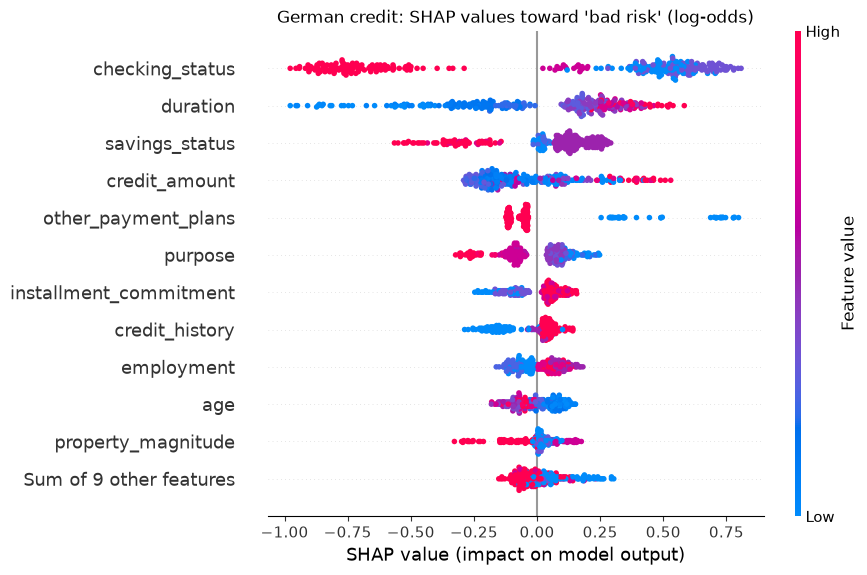

                        mean |SHAP|  perm AUC drop (test)  perm std  SHAP share
checking_status              0.5905                0.1450    0.0326      0.3013
duration                     0.2925                0.0484    0.0194      0.1493
savings_status               0.1794                0.0135    0.0078      0.0916
credit_amount                0.1680                0.0226    0.0097      0.0857
other_payment_plans          0.1284               -0.0016    0.0094      0.0655
purpose                      0.1128                0.0147    0.0052      0.0576
installment_commitment       0.0842                0.0053    0.0048      0.0430
credit_history               0.0807                0.0054    0.0033      0.0412
employment                   0.0686               -0.0039    0.0032      0.0350
age                          0.0679                0.0047    0.0031      0.0346

Spearman ρ between SHAP and permutation rankings: 0.69 (permutation on only 300 test applicants is noisy: look at 'perm

In [57]:
cr_background = Xc_tr.sample(100, random_state=SEED)
cr_explainer = shap.TreeExplainer(credit_model, data=cr_background, feature_perturbation="interventional")
sv_cr = cr_explainer(Xc_te)
print(f"additivity in log-odds: max error {np.abs(sv_cr.base_values + sv_cr.values.sum(axis=1) - credit_model.predict(Xc_te, raw_score=True)).max():.1e} | "
      f"base value {sv_cr.base_values[0]:.3f} log-odds = P(bad) {sigmoid(sv_cr.base_values[0]):.3f}")

shap.plots.beeswarm(sv_cr, max_display=12, show=False)
plt.title("German credit: SHAP values toward 'bad risk' (log-odds)")
plt.show()

cr_perm = permutation_importance(credit_model, Xc_te, yc_te, scoring="roc_auc", n_repeats=20, random_state=SEED)
cr_global = pd.DataFrame({"mean |SHAP|": np.abs(sv_cr.values).mean(axis=0), "perm AUC drop (test)": cr_perm.importances_mean,
                          "perm std": cr_perm.importances_std}, index=CR_FEATURES).sort_values("mean |SHAP|", ascending=False)
cr_global["SHAP share"] = cr_global["mean |SHAP|"] / cr_global["mean |SHAP|"].sum()
print(cr_global.head(10).round(4).to_string())
print(f"\nSpearman ρ between SHAP and permutation rankings: {spearmanr(cr_global['mean |SHAP|'], cr_global['perm AUC drop (test)']).statistic:.2f} "
      f"(permutation on only {len(yc_te)} test applicants is noisy: look at 'perm std')")

### Step 3 — Three real applicants: waterfall and top-3 reason codes

We pick a **clear reject** (highest risk), a **borderline reject** (just above the threshold), and a **clear approve** (lowest risk). A reason code is a feature whose SHAP value pushes toward *bad* (for rejections) — with the applicant's actual value in words.


CLEAR REJECT — test applicant #54: P(bad) = 0.766 → REJECT (truth: bad)
  adverse-action reasons (pushing toward bad risk):
   1. checking_status = <0 (+0.694 log-odds)
   2. duration = 48.0 (+0.479 log-odds)
   3. savings_status = <100 (+0.284 log-odds)

BORDERLINE REJECT — test applicant #106: P(bad) = 0.160 → REJECT (truth: good)
  adverse-action reasons (pushing toward bad risk):
   1. credit_amount = 5103.0 (+0.204 log-odds)
   2. duration = 24.0 (+0.201 log-odds)
   3. savings_status = <100 (+0.148 log-odds)

CLEAR APPROVE — test applicant #284: P(bad) = 0.058 → APPROVE (truth: good)
  strongest factors in favour (pushing toward good risk):
   1. duration = 4.0 (-0.538 log-odds)
   2. checking_status = no checking (-0.505 log-odds)
   3. credit_history = critical/other existing credit (-0.149 log-odds)

waterfall for the borderline reject (#106):


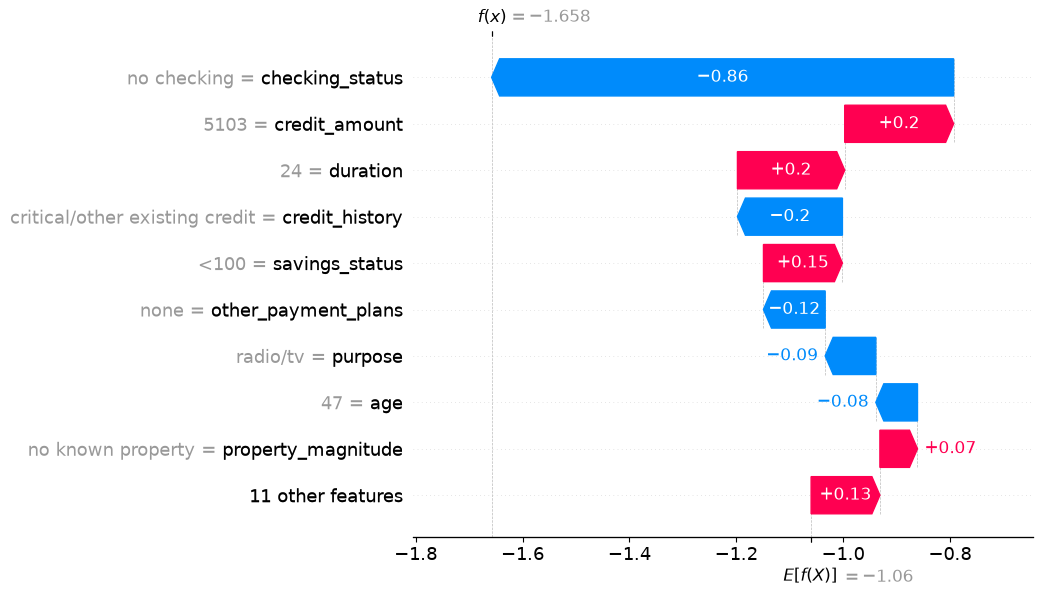

In [58]:
cr_display = shap.Explanation(values=sv_cr.values, base_values=sv_cr.base_values, data=sv_cr.data, feature_names=CR_FEATURES,
                              display_data=cr_raw.loc[cr_te_idx, CR_FEATURES].to_numpy())
rejected_pos, approved_pos = np.flatnonzero(reject), np.flatnonzero(~reject)
assert len(rejected_pos) and len(approved_pos), "need both decisions in the test set"
picks = {"clear reject": int(rejected_pos[np.argmax(p_bad[rejected_pos])]),
         "borderline reject": int(rejected_pos[np.argmin(p_bad[rejected_pos])]),
         "clear approve": int(approved_pos[np.argmin(p_bad[approved_pos])])}


def reason_codes(values, raw_row, k=3, toward_bad=True):
    """Top-k features pushing toward 'bad' (toward_bad=True) or toward 'good', with the applicant's real values."""
    contrib = pd.Series(values, index=CR_FEATURES).sort_values(ascending=not toward_bad)
    contrib = contrib[contrib > 0] if toward_bad else contrib[contrib < 0]
    return [(feat, raw_row[feat], float(val)) for feat, val in contrib.head(k).items()]


raw_te_cr = cr_raw.loc[cr_te_idx]
for label, pos in picks.items():
    rejected_here = bool(reject[pos])
    print(f"\n{label.upper()} — test applicant #{pos}: P(bad) = {p_bad[pos]:.3f} → {'REJECT' if rejected_here else 'APPROVE'} "
          f"(truth: {'bad' if yc_te[pos] else 'good'})")
    heading = "adverse-action reasons (pushing toward bad risk)" if rejected_here else "strongest factors in favour (pushing toward good risk)"
    print(f"  {heading}:")
    for rank, (feat, value, val) in enumerate(reason_codes(sv_cr.values[pos], raw_te_cr.iloc[pos], toward_bad=rejected_here), start=1):
        print(f"   {rank}. {feat} = {value!s} ({val:+.3f} log-odds)")

print(f"\nwaterfall for the borderline reject (#{picks['borderline reject']}):")
shap.plots.waterfall(cr_display[picks["borderline reject"]], max_display=10, show=False)
plt.show()

### Step 4 — Are the reasons stable?

Reason codes that change when you retrain with a different seed, or when you change the background sample, are hard to defend to a regulator. We measure the mean pairwise Jaccard overlap of each applicant's top-3 reason set across: 5 model seeds (row/column subsampling makes LightGBM random), 5 background samples, and 5 LIME seeds.

In [59]:
def reason_set(values, toward_bad, k=3):
    order = np.argsort(-values) if toward_bad else np.argsort(values)
    return set(order[:k].tolist())


seed_models = [lgb.LGBMClassifier(n_estimators=best_trees, random_state=s, **CR_PARAMS).fit(Xc_tr, yc_tr) for s in range(5)]
seed_svs = [shap.TreeExplainer(m, data=cr_background, feature_perturbation="interventional")(Xc_te).values for m in seed_models]
bg_svs = [shap.TreeExplainer(credit_model, data=Xc_tr.sample(100, random_state=500 + s), feature_perturbation="interventional")(Xc_te).values
          for s in range(5)]
cr_cat_idx = [CR_FEATURES.index(c) for c in CR_CAT]


def credit_proba(A):
    return credit_model.predict_proba(pd.DataFrame(A, columns=CR_FEATURES))


stability_cr = []
for label, pos in picks.items():
    toward_bad = bool(reject[pos])
    lime_sets = []
    for s in range(5):
        lime_cr = lime.lime_tabular.LimeTabularExplainer(Xc_tr.to_numpy(), mode="classification", feature_names=CR_FEATURES,
                                                         categorical_features=cr_cat_idx, class_names=["good", "bad"], random_state=s)
        weights = np.zeros(len(CR_FEATURES))
        for f, w in lime_cr.explain_instance(Xc_te.iloc[pos].to_numpy(), credit_proba, num_features=len(CR_FEATURES), num_samples=2000).as_map()[1]:
            weights[f] = w
        lime_sets.append(reason_set(weights, toward_bad))
    shap_set = reason_set(sv_cr.values[pos], toward_bad)
    stability_cr.append({"applicant": label,
                         "SHAP: 5 model seeds": mean_pairwise_jaccard([reason_set(v_[pos], toward_bad) for v_ in seed_svs]),
                         "SHAP: 5 backgrounds": mean_pairwise_jaccard([reason_set(v_[pos], toward_bad) for v_ in bg_svs]),
                         "LIME: 5 seeds": mean_pairwise_jaccard(lime_sets),
                         "SHAP vs LIME overlap": float(np.mean([len(shap_set & ls) / len(shap_set | ls) for ls in lime_sets]))})
stability_cr = pd.DataFrame(stability_cr).round(2)
print(stability_cr.to_string(index=False))
means = stability_cr.drop(columns="applicant").mean()
print(f"\naverage top-3 Jaccard → model seeds {means['SHAP: 5 model seeds']:.2f}, backgrounds {means['SHAP: 5 backgrounds']:.2f}, "
      f"LIME seeds {means['LIME: 5 seeds']:.2f}; most stable source: {means.drop('SHAP vs LIME overlap').idxmax()}")

        applicant  SHAP: 5 model seeds  SHAP: 5 backgrounds  LIME: 5 seeds  SHAP vs LIME overlap
     clear reject                  1.0                  1.0            1.0                   1.0
borderline reject                  1.0                  1.0            1.0                   1.0
    clear approve                  0.7                  1.0            1.0                   0.5

average top-3 Jaccard → model seeds 0.90, backgrounds 1.00, LIME seeds 1.00; most stable source: SHAP: 5 backgrounds


### Step 5 — Model-risk note (computed)

German credit's `personal_status` column mixes **sex and marital status** (e.g. "female div/dep/mar"), and `age` and `foreign_worker` are also sensitive. A validator would ask: does the model lean on them, and do outcomes differ by group?

In [60]:
sex_te = np.where(raw_te_cr["personal_status"].str.startswith("female"), "female", "male")
young_te = raw_te_cr["age"].to_numpy() < 25
rank_of = {f: i + 1 for i, f in enumerate(cr_global.index)}
age_shap = sv_cr.values[:, CR_FEATURES.index("age")]
group_rows = []
for name, mask in [("female (from personal_status)", sex_te == "female"), ("male (from personal_status)", sex_te == "male"),
                   ("age < 25", young_te), ("age ≥ 25", ~young_te)]:
    group_rows.append({"group": name, "applicants": int(mask.sum()), "rejection rate": reject[mask].mean(),
                       "true bad rate": yc_te[mask].mean()})
groups_df = pd.DataFrame(group_rows).round(3)
print(groups_df.to_string(index=False))

top3_share = cr_global["SHAP share"].head(3).sum()
sex_gap = groups_df.loc[0, "rejection rate"] - groups_df.loc[1, "rejection rate"]
age_gap = groups_df.loc[2, "rejection rate"] - groups_df.loc[3, "rejection rate"]
n_foreign_no = int((cr_raw.loc[cr_tr_idx, "foreign_worker"] == "no").sum())
print("\n📝 MODEL-RISK NOTE")
print(f"• Performance: test AUC {auc_cr:.3f} (logistic baseline {auc_cr_logit:.3f}); at threshold {THRESHOLD:.2f} the model rejects {reject.mean():.0%} "
      f"of applicants with cost {cost_model} vs {5 * yc_te.sum()} for approving everyone (the 5:1 cost matrix makes rejection cheap).")
print(f"  {'⚠️ The logistic baseline scores at least as well on this small dataset — prefer the glass-box model unless another requirement favours boosting.' if auc_cr_logit >= auc_cr else 'Boosting beats the logistic baseline on test.'}")
print(f"• Reliance: the top-3 features ({', '.join(cr_global.index[:3])}) carry {top3_share:.0%} of mean |SHAP|; "
      f"account status and loan terms dominate, as expected for credit risk.")
print(f"• Sensitive features: personal_status ranks #{rank_of['personal_status']}, age #{rank_of['age']}, foreign_worker #{rank_of['foreign_worker']} "
      f"of {len(CR_FEATURES)} by mean |SHAP|. Mean SHAP of age for under-25s {age_shap[young_te].mean():+.3f} vs {age_shap[~young_te].mean():+.3f} log-odds "
      f"→ youth {'raises' if age_shap[young_te].mean() > age_shap[~young_te].mean() else 'lowers'} predicted risk.")
print(f"• Outcomes: rejection-rate gap female − male {sex_gap:+.3f} (n={groups_df.loc[0, 'applicants']} women); under-25 − others {age_gap:+.3f} "
      f"(n={groups_df.loc[2, 'applicants']}). {'⚠️ gap above 10 points — review before use' if max(abs(sex_gap), abs(age_gap)) > 0.10 else 'gaps within 10 points'}; "
      f"small groups make these estimates noisy.")
print(f"• Data: only {n_foreign_no} training applicants are non-foreign workers, so any effect of foreign_worker is poorly estimated; "
      f"age and personal_status would be prohibited or restricted inputs in many jurisdictions — test a model without them and compare AUC and gaps.")
print(f"• Explanation stability (top-3 Jaccard): {means['SHAP: 5 model seeds']:.0%} across model seeds, {means['SHAP: 5 backgrounds']:.0%} across SHAP backgrounds, "
      f"{means['LIME: 5 seeds']:.0%} across LIME seeds; SHAP and LIME share {means['SHAP vs LIME overlap']:.0%} of reasons. Issue codes from SHAP "
      f"(they add up exactly to the score and are reproducible), and version the model and background set together.")

                        group  applicants  rejection rate  true bad rate
female (from personal_status)         101           0.693          0.347
  male (from personal_status)         199           0.663          0.276
                     age < 25          59           0.763          0.475
                     age ≥ 25         241           0.651          0.257

📝 MODEL-RISK NOTE
• Performance: test AUC 0.785 (logistic baseline 0.801); at threshold 0.16 the model rejects 67% of applicants with cost 166 vs 450 for approving everyone (the 5:1 cost matrix makes rejection cheap).
  ⚠️ The logistic baseline scores at least as well on this small dataset — prefer the glass-box model unless another requirement favours boosting.
• Reliance: the top-3 features (checking_status, duration, savings_status) carry 54% of mean |SHAP|; account status and loan terms dominate, as expected for credit risk.
• Sensitive features: personal_status ranks #12, age #10, foreign_worker #20 of 20 by mean |SHAP|. 

**Stretch goals**
1. Retrain **without** `personal_status`, `age`, and `foreign_worker`; compare test AUC, cost, and the group rejection-rate gaps. Does a proxy (e.g. `employment` or `housing`) take over their SHAP share?
2. Add **monotonic constraints** (`monotone_constraints` in LightGBM) so, e.g., longer `duration` can never lower risk, and check whether reason codes become more intuitive.
3. Map features to human-readable reason statements ("Checking account balance below 0 DM") and group correlated features (duration & credit_amount) into one reason.
4. Produce a counterfactual (section 11) for the borderline reject using only actionable features (`duration`, `credit_amount`, `savings_status`).

### 🗣️ How to talk about this in an interview
- "I validated the model with 5-fold CV against a logistic baseline and picked the decision threshold from out-of-fold predictions using the dataset's 5:1 cost matrix — the test set was evaluated once — and I flagged that on only 1,000 applicants the logistic baseline was just as good, which matters when interpretability is required."
- "For each rejected applicant I produced top-3 adverse-action reasons from interventional TreeSHAP in log-odds, verified that base value plus SHAP values reproduce the model's score exactly, and showed a waterfall for a borderline case."
- "I measured explanation stability — top-3 reason sets across model seeds, background samples, and LIME seeds — and checked where SHAP and LIME disagreed; I issued codes from SHAP because they add up exactly to the score and are reproducible once the model and background set are versioned together."
- "The computed risk note flagged sensitive inputs — `personal_status` encodes sex, plus age and foreign-worker status — reported rejection-rate gaps by group with their sample sizes, and recommended testing a model without them because proxies can carry the same signal."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What's the difference between global and local, and between intrinsic and post-hoc interpretability?**

<details><summary>Show answer</summary>

- **30-second answer:** Global explains the model overall (which features matter, the shape of effects); local explains one prediction. Intrinsic means the model is readable itself (linear weights, shallow trees, EBMs); post-hoc means a separate method explains a trained model (permutation importance, PDP, SHAP, LIME). Post-hoc methods are model-specific (TreeSHAP) or model-agnostic (only call `predict`).
- **Go deeper:** Local explanations aggregate into global ones (mean |SHAP|). Rudin (2019) argues for intrinsic models in high-stakes decisions when they're nearly as accurate — in our Adult example logistic regression was only a few AUC points behind LightGBM; measure that gap before choosing.
- **❌ Common wrong answer:** "Post-hoc explanations make a black box as trustworthy as a glass-box model."

</details>

**Q2. What are Shapley values, and which properties make SHAP attractive?**

<details><summary>Show answer</summary>

- **30-second answer:** A feature's Shapley value is its marginal contribution to the prediction, averaged over all orderings (coalitions) of features, with absent features filled from background data. It's the unique attribution satisfying efficiency (values sum to prediction minus the average prediction), symmetry, dummy (unused feature → 0), and additivity.
- **Go deeper:** Exact computation needs $2^M$ coalitions; TreeSHAP does it in polynomial time for trees ($O(TLD^2)$ per row, path-dependent); Permutation/KernelSHAP approximate for other models. SHAP's "consistency": if a model changes so a feature contributes more, its attribution doesn't decrease — split-count importance can violate that.
- **❌ Common wrong answer:** "A SHAP value is the change in prediction when you remove that one feature."

</details>

**Q3. SHAP vs LIME — when would you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** Both are local and model-agnostic. SHAP has theoretical guarantees (additivity, symmetry), is exact and fast for trees, and is deterministic with TreeSHAP; LIME fits a weighted linear surrogate around the row, depends on random sampling and an arbitrary kernel width, and its top features change between runs (we measured it). Default to SHAP for tabular models; LIME is a quick option for text/images or any model where speed matters more than rigor.
- **Go deeper:** LIME's surrogate R² tells you if the local line even fits. KernelSHAP is LIME with a specific kernel, loss and no regularization chosen so the result equals Shapley values.
- **❌ Common wrong answer:** "They give the same numbers, LIME is just faster."

</details>

**Q4. Why is impurity-based feature importance misleading, and what do you use instead?**

<details><summary>Show answer</summary>

- **30-second answer:** It's computed on training data and credits every split, so continuous or high-cardinality features (IDs, `fnlwgt`) collect importance from noise-fitting splits — our 20,000-level random ID ranked 3rd by split count but 14th of 15 by test permutation importance. Use permutation importance on held-out data or mean |SHAP|.
- **Go deeper:** Add a random "shadow" feature as a reference line; report repeat-to-repeat spread; for gain importance the bias is smaller but still present.
- **❌ Common wrong answer:** "`feature_importances_` shows which features cause the target."

</details>

**Q5. How do correlated features affect permutation importance, SHAP, and PDPs?**

<details><summary>Show answer</summary>

- **30-second answer:** Permutation creates unrealistic rows and lets the model fall back on the twin, so each correlated feature can look unimportant; SHAP splits credit between twins arbitrarily (depending on which the model used); PDPs average predictions over impossible combinations (our Latitude PDP put 39% of its synthetic districts far from any real one). Group correlated features, de-duplicate, or use conditional methods / ALE.
- **Go deeper:** Interventional SHAP breaks correlations by design (it explains the model's function); path-dependent TreeSHAP partly respects them through tree cover. Whether a model uses one twin or both depends on training randomness such as feature subsampling.
- **❌ Common wrong answer:** "Correlated features don't matter for tree models."

</details>

**Q6. Interventional vs path-dependent (observational) TreeSHAP — what's the difference?**

<details><summary>Show answer</summary>

- **30-second answer:** Path-dependent uses the trees' training cover to average over both branches when a feature is "absent" — no background data, very fast, approximates conditional expectations. Interventional replaces absent features with values from a background dataset — breaks feature dependence, needs 100–1,000 background rows, costs $O(TLB)$ per row, and supports explaining transformed outputs like probability.
- **Go deeper:** Base values differ (training cover vs background mean). On Adult the global rankings agreed almost perfectly but individual values differed. Keep additivity checks on — some model/version combinations fail them.
- **❌ Common wrong answer:** "They're the same algorithm; interventional is just slower."

</details>

**Q7. Does a large SHAP value mean the feature causes the outcome?**

<details><summary>Show answer</summary>

- **30-second answer:** No. SHAP explains the model's output, which learns associations; confounded or proxy features get credit. `relationship = Husband` has a big SHAP value on Adult, but husbands also differ in age and hours worked. Causal questions need experiments or causal inference.
- **Go deeper:** Dropping `sex` barely changed the men/women flag-rate gap because relationship/marital status predict sex with a cross-validated AUC ≈ 0.88 — "fairness through unawareness" fails; audit outcomes per group instead.
- **❌ Common wrong answer:** "If SHAP says marital status matters, getting married will raise your income."

</details>

**Q8. What's the difference between a PDP, an ICE plot, and ALE?**

<details><summary>Show answer</summary>

- **30-second answer:** ICE: one what-if curve per row as a feature sweeps a grid. PDP: the average of the ICE curves. ALE: accumulates local prediction changes within quantile bins using only rows actually in each bin, so it doesn't extrapolate when features are correlated.
- **Go deeper:** Crossing or fanning ICE curves reveal interactions the PDP hides; centered ICE (c-ICE) makes shape differences visible; 2-D PDPs show pairwise interactions.
- **❌ Common wrong answer:** "A flat PDP proves the feature has no effect." (Opposite effects in subgroups can cancel.)

</details>

### 💻 Coding

**Q9. Implement permutation importance.**

<details><summary>Show answer</summary>

- **30-second answer:** `base = score(model, X_val, y_val)`; for each column: repeat R times: copy X, shuffle that column (`X[col] = X[col].to_numpy()[rng.permutation(n)]`), record `base − score`; return mean and std per column.
- **Go deeper:** Use held-out data; allow groups of columns (one-hot or correlated sets) shuffled with the same permutation; for exact reproducibility of scikit-learn's numbers mimic its seeding (one seed shared by all columns, cumulative reshuffles) — we asserted equality in the build section.
- **❌ Common wrong answer:** Dropping the column and re-predicting without retraining (the model can't accept fewer columns), or shuffling the training set.

</details>

**Q10. Compute exact Shapley values for a model with few features. What's the complexity?**

<details><summary>Show answer</summary>

- **30-second answer:** Enumerate all $2^M$ coalitions, compute $v(S)$ as the mean prediction with features in $S$ fixed to $x$ and the rest from background rows, then $\phi_j = \sum_{S\not\ni j}\frac{|S|!(M-|S|-1)!}{M!}(v(S\cup j)-v(S))$. Cost $O(2^M \cdot |B|)$ predictions.
- **Go deeper:** Batch all coalitions into one prediction call (we did 256 × 50 rows at once); index coalitions as bitmasks so $S\cup\{j\}$ is `k + 2^(M-1-j)`; verify with the efficiency property and `shap.explainers.Exact`.
- **❌ Common wrong answer:** "Remove each feature once and measure the change" — that's leave-one-out, not Shapley, and it misallocates interactions.

</details>

### 🐛 Debugging Scenarios

**Q11. Your churn model has AUC 0.99 and SHAP shows `days_since_cancellation_request` dominates. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Target leakage — the feature is only known after the outcome starts. Remove it, rebuild features with point-in-time correctness, and re-evaluate; the realistic AUC will drop. Our Titanic `has_boat` pitfall showed the same signature: a too-good score and one feature holding most of the SHAP mass.
- **Go deeper:** Make "top SHAP features reviewed by a domain expert" a release gate; check each feature's timestamp relative to the prediction time; compare offline performance with a shadow deployment.
- **❌ Common wrong answer:** "Great, that feature is a strong predictor — ship it."

</details>

**Q12. The LIME explanation for the same customer changes every time you run it. Is something broken?**

<details><summary>Show answer</summary>

- **30-second answer:** No — LIME samples random perturbations and fits a weighted local model, so results vary; with 500 samples two Adult runs shared only about three-quarters of their top-5 features (Jaccard), while SHAP's sets were identical. Fix the `random_state`, raise `num_samples`, check the surrogate's R² (`exp.score`), and prefer SHAP (TreeSHAP is deterministic) when explanations must be reproducible.
- **Go deeper:** Also try several kernel widths — if the top features change a lot, the local linear approximation is fragile for that row.
- **❌ Common wrong answer:** "Just set a seed and the explanation becomes correct."

</details>

**Q13. You summed a classifier's SHAP values and got −1.4, but the model predicts 0.2. Where's the bug?**

<details><summary>Show answer</summary>

- **30-second answer:** TreeSHAP explains the log-odds margin, not the probability: $\sigma(\text{base} + \sum\phi) = \sigma(-1.4) \approx 0.198$ ✓. Convert once at the end, or use `model_output="probability"` with interventional TreeSHAP for probability-scale attributions.
- **Go deeper:** Also remember you must add the base value; `shap` checks additivity by default and raises if base + Σφ doesn't match the model output — never disable it silently.
- **❌ Common wrong answer:** "SHAP values are approximate, so they don't add up."

</details>

### 🏗️ Design

**Q14. Design adverse-action reason codes for a credit model serving 1M decisions a day.**

<details><summary>Show answer</summary>

- **30-second answer:** Gradient-boosted model with monotonic constraints; at scoring time compute TreeSHAP in log-odds against a **pinned** background set (versioned with the model); take the top-k features pushing toward rejection, map them (and grouped correlated features) to approved human-readable reason statements; store score, SHAP vector, model and background version for audit. Validate stability across retrains and fairness by group before release.
- **Go deeper:** TreeSHAP on a few hundred trees is ~ms per row — fine inline or as an async job; monitor drift in SHAP distributions (a feature's share jumping is an early warning); exclude or review protected attributes and their proxies; pair reasons with counterfactual guidance; see the system-design treatment in [ML System Design](../15_Interview_Prep/03_ML_System_Design.ipynb).
- **❌ Common wrong answer:** "Show the global feature importance chart to every rejected applicant."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** A classifier's base value is −1.2 log-odds and a row's SHAP values are `[0.8, 0.9, -0.1]`. What probability does the model predict?
<details><summary>Answer</summary>

**≈ 0.599** — σ(−1.2 + 1.6) = σ(0.4).
</details>

**2.** Linear model $f(x) = 3x_1 + 2x_2$, background mean $(1, 1)$, independent masker. What are the SHAP values for $x = (2, 0)$?
<details><summary>Answer</summary>

**(3, −2)** — $\phi_j = w_j(x_j - \mathbb E[x_j])$: $3(2-1)$ and $2(0-1)$. They sum to $f(x) - \mathbb E[f] = 6 - 5 = 1$.
</details>

**3.** $f(x) = x_1 \cdot x_2$, a single background row $(0, 0)$, explain $x = (1, 1)$. What are the Shapley values?
<details><summary>Answer</summary>

**(0.5, 0.5)** — $v(\varnothing)=v(\{1\})=v(\{2\})=0$, $v(\{1,2\})=1$; the pure interaction is split equally (symmetry).
</details>

**4.** A feature's permutation importance on the validation set is −0.002 ± 0.003. What does that mean?
<details><summary>Answer</summary>

**Effectively zero** — shuffling it doesn't hurt; the small negative value is noise (a random shuffle happened to score slightly better). Consider dropping it, but check it has no correlated twin first.
</details>

**5.** You explain the same row twice with `shap.TreeExplainer(model)` and twice with LIME using different `random_state` values. Which explanations are identical?
<details><summary>Answer</summary>

**Only the two TreeSHAP ones** — TreeSHAP is deterministic; LIME samples random perturbations, so its weights (and often its top features) change with the seed.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Inspection](https://scikit-learn.org/stable/inspection.html) — permutation importance and partial dependence in one place
- [scikit-learn — Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html) — the algorithm, and why to use held-out data
- [scikit-learn — Partial Dependence and Individual Conditional Expectation plots](https://scikit-learn.org/stable/modules/partial_dependence.html) — PDP/ICE math and the `recursion` vs `brute` methods
- [scikit-learn — Permutation Importance with Multicollinear or Correlated Features](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html) — clustering correlated features before computing importance
- [scikit-learn — Common pitfalls in the interpretation of coefficients of linear models](https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html) — scaling, correlation, and causal over-reach
- [SHAP documentation](https://shap.readthedocs.io/en/latest/) · [An introduction to explainable AI with Shapley values](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html) — the official walkthrough by SHAP's authors
- [GitHub — marcotcr/lime](https://github.com/marcotcr/lime) — LIME's reference implementation and tutorials

### 🎥 Videos
- [Scott Lundberg, Microsoft Research — Explainable Machine Learning with Shapley Values (#H2OWorld)](https://www.youtube.com/watch?v=ngOBhhINWb8) — H2O.ai, 18 min: the creator of SHAP on why Shapley values, TreeSHAP, and real medical case studies
- [DeepFindr — Explainable AI explained! #4 SHAP](https://www.youtube.com/watch?v=9haIOplEIGM) — 16 min: Shapley values, KernelSHAP and a hands-on code walkthrough
- [DeepFindr — Explainable AI explained! #3 LIME](https://www.youtube.com/watch?v=d6j6bofhj2M) — 14 min: perturbation, the proximity kernel, and the local surrogate, like section 10
- [A Data Odyssey — Partial Dependence (PDPs) and Individual Conditional Expectation (ICE) Plots | Intuition and Math](https://www.youtube.com/watch?v=dEhbS37Kglc) — 12 min: PDP/ICE formulas and their correlated-feature weakness, like section 5

### 📄 Papers
- [Lundberg & Lee (2017) — A Unified Approach to Interpreting Model Predictions](https://arxiv.org/abs/1705.07874) — SHAP, its axioms, and KernelSHAP
- [Ribeiro, Singh & Guestrin (2016) — "Why Should I Trust You?": Explaining the Predictions of Any Classifier](https://arxiv.org/abs/1602.04938) — LIME
- [Lundberg et al. (2020) — From local explanations to global understanding with explainable AI for trees](https://www.nature.com/articles/s42256-019-0138-9) — TreeSHAP, interaction values, Nature Machine Intelligence
- [Goldstein et al. (2013) — Peeking Inside the Black Box: Visualizing Statistical Learning with Plots of Individual Conditional Expectation](https://arxiv.org/abs/1309.6392) — ICE plots
- [Apley & Zhu (2016) — Visualizing the Effects of Predictor Variables in Black Box Supervised Learning Models](https://arxiv.org/abs/1612.08468) — ALE plots
- [Wachter, Mittelstadt & Russell (2017) — Counterfactual Explanations without Opening the Black Box: Automated Decisions and the GDPR](https://arxiv.org/abs/1711.00399) — counterfactual explanations

### 📘 Books & Courses
- [Christoph Molnar — Interpretable Machine Learning](https://christophm.github.io/interpretable-ml-book/) — free online book covering every method here (plus ALE, anchors, and more) in depth
- [InterpretML](https://interpret.ml/) — Microsoft's toolkit with Explainable Boosting Machines (the glass-box GAM from section 2)

### 🏋️ Practice
- [Kaggle Learn — Machine Learning Explainability](https://www.kaggle.com/learn/machine-learning-explainability) — short hands-on lessons on permutation importance, partial dependence, and SHAP

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Global vs local | model-wide vs one-prediction explanations | mean \|SHAP\| · permutation importance · PDP vs SHAP values · ICE · LIME |
| Coefficients & odds ratios | intrinsic explanation of linear/logistic models | standardize first; odds ratio $= e^{w}$ per SD |
| Impurity importance | split count / gain on training data — biased | `booster_.feature_importance("split" \| "gain")`, `feature_importances_` |
| Permutation importance | score drop when a column is shuffled (held-out) | `permutation_importance(model, X_val, y_val, scoring=..., n_repeats=...)` |
| Correlated features | twins share or hide importance | shuffle groups together; de-duplicate; cluster |
| PDP / ICE | average / per-row what-if curves | `PartialDependenceDisplay.from_estimator(..., kind="both")`; beware extrapolation → ALE |
| Shapley value | fair average marginal contribution | $\phi_j=\sum_S \frac{\lvert S\rvert!(M-\lvert S\rvert-1)!}{M!}[v(S\cup j)-v(S)]$; efficiency, symmetry, dummy, additivity |
| TreeSHAP | exact SHAP for trees, log-odds for classifiers | `shap.TreeExplainer(model)(X)`; `feature_perturbation="interventional"` with `data=`; $\sigma(\phi_0+\sum\phi_j)=p$ |
| Model-agnostic SHAP | SHAP for any `predict` function | `shap.explainers.Permutation/Exact(f, shap.maskers.Independent(bg))`; `LinearExplainer`: $w_j(x_j-\bar x_j)$ |
| SHAP plots | waterfall (local), beeswarm & bar (global), scatter (dependence) | `shap.plots.waterfall/beeswarm/bar/scatter` |
| LIME | weighted local linear surrogate — unstable | `LimeTabularExplainer(...).explain_instance(x, predict_proba, num_samples=...)`; kernel $0.75\sqrt{d}$ |
| Counterfactuals | minimal actionable change that flips the decision | search over actionable features, cost in SD units |
| Causality & proxies | explanations describe the model, not the world | audit group outcomes; removing a column ≠ removing its signal |
| Debugging | leakage = too-good score + one dominant SHAP feature | review top features against prediction-time availability |

## ➡️ What's Next

**[19 · Recommender Systems](19_Recommender_Systems.ipynb)** — you can now explain what a model relies on for one decision; next you'll build models whose output is a *ranked list* per user — popularity, content-based, collaborative filtering, matrix factorization, and implicit-feedback ALS on real MovieLens data — and learn to evaluate them with ranking metrics like NDCG@k.